# ASSIGNMENT 06: RECURRENT NEURAL NETWORKS (RNN)
## Notebook 04: Dự Báo Doanh Thu Bán Lẻ Trực Tuyến (Online Retail) Bằng TensorFlow / Keras Vanilla RNN
### Phần 1: Phân Tích Giao Dịch, Làm Sạch Dữ Liệu, Tổng Hợp Theo Ngày, EDA & Chuẩn Bị Tensor Keras
### Phần 2: Xây Dựng Mô Hình (`tf.keras.Sequential` -> `SimpleRNN` -> `Dense`), Huấn Luyện, Dự Đoán, Đánh Giá & So Sánh Với PyTorch

---

> [!IMPORTANT]
> **Phạm vi thực hiện của Notebook 04**:
> Notebook này triển khai trọn vẹn hai giai đoạn:
> 1. **Giai đoạn 1 (Phần 1)**: Tiền xử lý dữ liệu giao dịch thực tế, tổng hợp chuỗi thời gian theo ngày, khám phá dữ liệu (EDA) và chuẩn bị tensor tương thích TensorFlow / Keras.
> 2. **Giai đoạn 2 (Phần 2)**: Xây dựng mô hình **Vanilla RNN** bằng `tf.keras.Sequential` với `SimpleRNN` và `Dense` (tuyệt đối **KHÔNG dùng LSTM/GRU**), compile với `Adam` + `MSE`, huấn luyện bằng `model.fit()` có **validation**, theo dõi và vẽ **learning curve**, dự đoán test set bằng `model.predict()`, khôi phục đơn vị gốc (GBP £) và đánh giá bằng **MAE, MSE, RMSE, MAPE**.

---

### Mục tiêu tổng thể của Notebook 04:
1. **Đọc nguồn dữ liệu thực tế**: Truy xuất trực tiếp bộ dữ liệu kinh điển **Online Retail II** (`dataset/online_retail_II.csv` với hơn 1 triệu dòng giao dịch), không dùng dữ liệu nhân tạo.
2. **Khảo sát cấu trúc & 12 tiêu chí chất lượng dữ liệu giao dịch**:
   * Kích thước mảng dữ liệu (Dimensions: rows, columns).
   * Danh sách tên cột (Columns).
   * Kiểu dữ liệu từng trường (Datatypes).
   * Giá trị khuyết thiếu (Missing values: `Customer ID`, `Description`).
   * Bản ghi trùng lặp (Duplicates).
   * Hóa đơn hủy (Cancelled invoices: mã bắt đầu bằng `'C'`).
   * Số lượng mặt hàng âm (`Quantity < 0`).
   * Đơn giá bất thường (`Price <= 0`: quà tặng, hàng mẫu, điều chỉnh công nợ).
   * Khung thời gian thực tế (Date range: từ 12/2009 đến 12/2011).
   * Phân bố thị trường quốc gia (Countries: tỷ trọng áp đảo của United Kingdom).
   * Số lượng khách hàng duy nhất (Customers).
   * Số lượng hóa đơn duy nhất (Transactions).
3. **Kỹ thuật tạo đặc trưng (Feature Engineering)**:
   * Tính toán biến doanh thu: $\text{Revenue} = \text{Quantity} \times \text{UnitPrice}$ ($\text{Price}$).
   * Thiết lập bộ lọc dữ liệu bán hàng hợp lệ (Valid transactions filter).
4. **Tổng hợp chuỗi thời gian theo ngày (Daily Aggregation)**:
   * Chuyển đổi dữ liệu giao dịch bất đồng bộ (Irregular timestamps) thành chuỗi các ngày có giao dịch theo thứ tự thời gian.
   * Tính toán 4 chỉ số cốt lõi: `daily_revenue`, `daily_quantity`, `transaction_count`, `avg_order_value`.
5. **Khám phá & Trực quan hóa dữ liệu chuỗi thời gian (EDA)**:
   * Phân bố doanh thu hàng ngày (`daily_revenue distribution`).
   * Sản lượng bán hàng ngày (`daily_quantity`).
   * Số lượng đơn hàng mỗi ngày (`transaction_count`).
   * Xu hướng biến thiên thời gian kèm đường trung bình động (SMA 7 quan sát và SMA 30 quan sát).
6. **Phân tích hình học phân bố, dị biệt & tính mùa vụ (Seasonality & Outliers)**:
   * Độ lệch (Skewness) và độ nhọn (Kurtosis).
   * Phát hiện các ngày doanh số đột biến cực hạn (Outliers > Mean + 3*Std).
   * Khám phá hiện tượng ngày khuyết (Missing Dates): phát hiện 104 ngày Thứ Bảy không có giao dịch sau lọc.
   * Kiểm chứng thực nghiệm chu kỳ tuần (Weekly pattern) và tính mùa vụ bùng nổ cuối năm (Q4 Seasonality).
7. **Thiết kế bài toán RNN & Lựa chọn Target**:
   * Chỉ định biến mục tiêu cốt lõi: `daily_revenue` tại thời điểm $t+1$.
   * Thiết kế bài toán đa biến (Multivariate Time Series) với $D = 4$ đặc trưng.
8. **Thiết kế cửa sổ trượt (Sliding Window Formulation)**:
   * Lựa chọn `sequence_length = 14` ngày giao dịch (14 ngày có giao dịch).
9. **Phân chia dữ liệu theo trục thời gian (Chronological Split)**:
   * 70% Train, 15% Validation, 15% Test nối tiếp theo thời gian, chống rò rỉ dữ liệu (Data Leakage).
10. **Chuẩn hóa dữ liệu (Scaling)**:
    * Áp dụng `MinMaxScaler(0, 1)`, tuân thủ nguyên tắc sống còn: **FIT CHỈ TRÊN TẬP TRAIN**.
11. **Chuẩn bị cấu trúc Tensor tương thích TensorFlow / Keras**:
    * Chuyển đổi sang mảng NumPy 3D `(num_samples, sequence_length, num_features)` kiểu `np.float32`.
    * Đóng gói tensor tương thích TensorFlow / Keras bằng `keras.ops.convert_to_tensor` (kiểu `float32`) với cấu hình `batch_size = 16` sẵn sàng cho `model.fit()`.
    * In đầy đủ kích thước các mảng (`X_train.shape`, `y_train.shape`, `X_val.shape`, `y_val.shape`, `X_test.shape`, `y_test.shape`).
12. **Bảng tổng kết thông số Giai đoạn 1**: Xác nhận trạng thái **`Ready for Keras RNN`**.

---

### Mục tiêu Giai đoạn 2 của Notebook 04 (Phần 2 - Mô hình hóa, Huấn luyện & Đánh giá):
13. **Thiết lập tính tái lập (Reproducibility)**: Cố định Random Seed và xác nhận phiên bản TensorFlow / Keras cùng backend đang sử dụng.
14. **Xây dựng kiến trúc mô hình Vanilla RNN bằng `tf.keras.Sequential`**: `Input(14, 4)` -> `SimpleRNN(32, tanh)` -> `Dense(1)`. Tuyệt đối không dùng LSTM/GRU.
15. **Cấu hình `model.compile()`**: Bộ tối ưu `Adam` và hàm mất mát `MSE`.
16. **Huấn luyện bằng `model.fit()`**: Có `validation_data=(X_val, y_val)`, theo dõi đồng thời Training Loss và Validation Loss qua từng epoch.
17. **Vẽ Learning Curve**: Trực quan hóa `loss` và `val_loss` trên cả thang đo tuyến tính và logarit.
18. **Dự đoán Test Set bằng `model.predict()`**: Khôi phục về đơn vị gốc GBP (£) bằng `inverse_transform`.
19. **Đánh giá định lượng**: MAE, MSE, RMSE, MAPE — kèm xử lý đúng và minh bạch trường hợp giá trị thực tế bằng 0 hoặc tiệm cận 0.
20. **Trực quan hóa Actual vs Predicted theo thời gian**: So sánh đường doanh thu thực tế và đường dự đoán của mô hình.
21. **Phân tích chuyên sâu**: Mẫu hình mô hình học được, vị trí sai số lớn, tác động của outlier, tác động của missing dates, điểm mạnh/hạn chế của việc aggregate giao dịch -> chuỗi ngày và hạn chế của SimpleRNN.
22. **So sánh PyTorch và Keras**: Đối chiếu implementation của notebook 02 (PyTorch) và notebook 04 (Keras) trên 5 khía cạnh: model, training, validation, prediction, evaluation (không xếp hạng framework).
23. **Final Conclusion**: Tổng kết dataset, preprocessing, bài toán forecasting, sequence length, model, metrics, kết quả và limitations.

---

### Bảng Mục Lục Điều Hướng:
1. [Xác Định & Đọc File Dataset Thực Tế](#section-1)
2. [Phân Tích Chi Tiết 12 Tiêu Chí Của Dataset Gốc](#section-2)
3. [Tạo Biến Doanh Thu (Revenue) & Lọc Giao Dịch Hợp Lệ](#section-3)
4. [Chuyển Đổi Dữ Liệu Giao Dịch Thành Chuỗi Thời Gian (Daily Aggregation)](#section-4)
5. [Khám Phá & Trực Quan Hóa Dữ Liệu Chuỗi Thời Gian (EDA)](#section-5)
6. [Phân Tích Phân Bố, Dị Biệt, Missing Dates & Kiểm Chứng Mùa Vụ](#section-6)
7. [Thiết Kế Bài Toán RNN & Lựa Chọn Target Forecasting Rõ Ràng](#section-7)
8. [Thiết Kế Cửa Sổ Trượt (Sliding Window Formulation)](#section-8)
9. [Phân Chia Train / Validation / Test Theo Trục Thời Gian](#section-9)
10. [Chuẩn Hóa Dữ Liệu (Scaling: FIT Chỉ Trên Tập Train)](#section-10)
11. [Tạo Cấu Trúc Tensor Tương Thích TensorFlow / Keras](#section-11)
12. [Ready for Keras RNN (Bảng Tổng Kết & Sẵn Sàng Huấn Luyện)](#section-12)

**PHẦN 2 — MÔ HÌNH HÓA, HUẤN LUYỆN & ĐÁNH GIÁ:**

13. [Thiết Lập Tính Tái Lập & Môi Trường TensorFlow / Keras](#section-13)
14. [Xây Dựng Mô Hình Keras Sequential Vanilla RNN (SimpleRNN + Dense)](#section-14)
15. [Cấu Hình Compile Mô Hình (Optimizer Adam & Loss MSE)](#section-15)
16. [Huấn Luyện Mô Hình Với model.fit() & Validation](#section-16)
17. [Đường Cong Học Tập (Learning Curve - Train / Validation Loss)](#section-17)
18. [Dự Đoán Test Set Bằng model.predict() & Inverse Transform](#section-18)
19. [Đánh Giá Định Lượng: MAE, MSE, RMSE, MAPE & Xử Lý Giá Trị Bằng 0](#section-19)
20. [Trực Quan Hóa Actual vs Predicted Theo Thời Gian](#section-20)
21. [Phân Tích Chuyên Sâu Kết Quả & Giới Hạn Mô Hình](#section-21)
22. [So Sánh Implementation: PyTorch (Notebook 02) vs TensorFlow / Keras (Notebook 04)](#section-22)
23. [Final Conclusion (Tổng Kết Cuối Cùng)](#section-23)


---
<a id="section-1"></a>
## 1. Xác Định & Đọc File Dataset Thực Tế

### 1.1. Nguồn gốc & Môi trường lưu trữ:
* **Bộ dữ liệu**: Online Retail II Data Set.
* **Nguồn lưu trữ**: Kaggle - *Online Retail Dataset* (tác giả Lakshmi) / UCI Machine Learning Repository. [Link Kaggle Dataset](https://www.kaggle.com/datasets/lakshmi25npathi/online-retail-dataset)
* **Vị trí tệp trong thư mục Assignment 06**: `dataset/online_retail_II.csv`.
* **Đặc tính kinh doanh**: Bộ dữ liệu chứa toàn bộ các giao dịch thực tế diễn ra trong giai đoạn từ ngày **01/12/2009** đến ngày **09/12/2011** của một doanh nghiệp thương mại điện tử có trụ sở tại Vương Quốc Anh (UK-based online retail), chuyên bán buôn và bán lẻ các mặt hàng quà tặng độc đáo trên toàn cầu.

Đoạn mã bên dưới kiểm tra sự tồn tại của tệp trên đĩa cứng và nạp dữ liệu bằng Pandas.


In [1]:
# 1. Kiểm tra sự tồn tại của file và nạp dataset thực tế bằng Pandas
import os
import sys
import pandas as pd
import numpy as np

# Đảm bảo xuất chuẩn UTF-8
if hasattr(sys.stdout, 'reconfigure'):
    sys.stdout.reconfigure(encoding='utf-8')

candidate_paths = [
    os.path.join("dataset", "online_retail_II.csv"),
    os.path.join("Assignment 06", "dataset", "online_retail_II.csv"),
    os.path.join("..", "dataset", "online_retail_II.csv")
]
dataset_path = next((p for p in candidate_paths if os.path.exists(p)), None)

if dataset_path is None:
    raise FileNotFoundError(f"Lỗi: Không tìm thấy file dữ liệu tại các đường dẫn: {candidate_paths}")

file_size_bytes = os.path.getsize(dataset_path)
file_size_mb = file_size_bytes / (1024 * 1024)

print("=== XÁC THỰC FILE DỮ LIỆU THỰC TẾ ===")
print(f"-> Đường dẫn file : {dataset_path}")
print(f"-> Dung lượng file: {file_size_mb:.2f} MB ({file_size_bytes:,} bytes)")

# Đọc dữ liệu vào DataFrame với tham số low_memory=False để tối ưu kiểu dữ liệu
df_raw = pd.read_csv(dataset_path, low_memory=False)
print(f"-> Đã nạp thành công: {len(df_raw):,} dòng giao dịch, {df_raw.shape[1]} cột đặc trưng.")


=== XÁC THỰC FILE DỮ LIỆU THỰC TẾ ===
-> Đường dẫn file : dataset\online_retail_II.csv
-> Dung lượng file: 89.88 MB (94,248,800 bytes)


-> Đã nạp thành công: 1,067,371 dòng giao dịch, 8 cột đặc trưng.


---
<a id="section-2"></a>
## 2. Phân Tích Chi Tiết 12 Tiêu Chí Của Dataset Gốc

Để có cái nhìn toàn cảnh và khoa học về bản chất của bộ dữ liệu giao dịch, chúng ta tiến hành khảo sát chi tiết **12 tiêu chí kỹ thuật**:

1. **Dimensions (Kích thước)**: Tổng số lượng bản ghi và số lượng trường dữ liệu.
2. **Columns (Danh sách cột)**: 8 cột đặc trưng: `Invoice`, `StockCode`, `Description`, `Quantity`, `InvoiceDate`, `Price`, `Customer ID`, `Country`.
3. **Datatypes (Kiểu dữ liệu)**: Định dạng kiểu lưu trữ của từng cột trên bộ nhớ.
4. **Missing Values (Giá trị khuyết thiếu)**: Đánh giá tỷ lệ khuyết thiếu trên các trường, đặc biệt là `Customer ID` và `Description`.
5. **Duplicates (Dòng trùng lặp)**: Các giao dịch bị ghi nhận lặp lại nguyên vẹn.
6. **Cancelled Invoices (Hóa đơn bị hủy)**: Các mã hóa đơn bắt đầu bằng ký tự `'C'` (ví dụ `C489449`).
7. **Negative Quantities (Số lượng âm)**: Các dòng có `Quantity < 0` (hàng trả lại, xuất kho điều chỉnh hư hỏng).
8. **Price Anomalies (Đơn giá bất thường)**: Các dòng có `Price <= 0` (quà tặng 0 đồng, chiết khấu, điều chỉnh nợ xấu kế toán).
9. **Date Range (Khung thời gian)**: Mốc ngày giao dịch sớm nhất và muộn nhất.
10. **Countries (Thị trường quốc gia)**: Phân bố địa lý khách hàng, xác định thị trường chủ đạo.
11. **Customers (Khách hàng)**: Số lượng tài khoản định danh duy nhất.
12. **Transactions (Giao dịch)**: Tổng số hóa đơn giao dịch duy nhất được phát hành.


In [2]:
# 2. Phân tích chi tiết 12 tiêu chí chất lượng dữ liệu của Online Retail Dataset
print("================================================================================")
print("=== BÁO CÁO KHẢO SÁT CHI TIẾT 12 TIÊU CHÍ KỸ THUẬT DATASET GỐC ===")
print("================================================================================")

# 1. Dimensions
n_rows, n_cols = df_raw.shape
print(f"1. Dimensions       : {n_rows:,} dòng x {n_cols} cột")

# 2. Columns
print(f"2. Columns          : {list(df_raw.columns)}")

# 3. Datatypes & Memory
print("\n3. Datatypes & Cấu trúc bộ nhớ:")
display(df_raw.dtypes.to_frame(name='Kiểu dữ liệu (Dtype)'))

# 4. Missing values
missing_counts = df_raw.isnull().sum()
missing_ratios = (missing_counts / n_rows) * 100
df_missing = pd.DataFrame({
    'Số lượng khuyết': missing_counts,
    'Tỷ lệ khuyết (%)': missing_ratios
})
print("\n4. Missing Values (Giá trị khuyết thiếu):")
display(df_missing)

# 5. Duplicates
n_duplicates = df_raw.duplicated().sum()
print(f"\n5. Duplicates        : {n_duplicates:,} dòng trùng lặp ({n_duplicates/n_rows*100:.2f}%)")

# 6. Cancelled invoices (Mã hóa đơn bắt đầu bằng 'C')
df_raw['InvoiceStr'] = df_raw['Invoice'].astype(str)
cancelled_mask = df_raw['InvoiceStr'].str.startswith('C')
n_cancelled = cancelled_mask.sum()
print(f"6. Cancelled Invoices: {n_cancelled:,} dòng ({n_cancelled/n_rows*100:.2f}%)")

# 7. Negative quantities
n_neg_qty = (df_raw['Quantity'] < 0).sum()
print(f"7. Negative Quantity : {n_neg_qty:,} dòng ({n_neg_qty/n_rows*100:.2f}%)")

# 8. Price anomalies (Price <= 0)
n_price_anom = (df_raw['Price'] <= 0).sum()
print(f"8. Price Anomalies   : {n_price_anom:,} dòng ({n_price_anom/n_rows*100:.2f}%)")

# 9. Date range
raw_dates = pd.to_datetime(df_raw['InvoiceDate'])
min_date = raw_dates.min()
max_date = raw_dates.max()
print(f"9. Date Range        : Từ {min_date} đến {max_date} ({(max_date - min_date).days} ngày dương lịch)")

# 10. Countries
n_countries = df_raw['Country'].nunique()
top_country = df_raw['Country'].value_counts().index[0]
top_country_count = df_raw['Country'].value_counts().iloc[0]
print(f"10. Countries        : {n_countries} quốc gia (Thị trường lớn nhất: '{top_country}' chiếm {top_country_count:,} dòng ~ {top_country_count/n_rows*100:.2f}%)")

# 11. Customers
n_unique_customers = df_raw['Customer ID'].nunique()
print(f"11. Customers        : {n_unique_customers:,} khách hàng định danh duy nhất")

# 12. Transactions
n_unique_invoices = df_raw['Invoice'].nunique()
print(f"12. Transactions     : {n_unique_invoices:,} hóa đơn giao dịch duy nhất")
print("================================================================================")

# Hiển thị 5 dòng đầu tiên làm mẫu trực quan
print("\n5 dòng đầu tiên của dữ liệu thô:")
display(df_raw.head())


=== BÁO CÁO KHẢO SÁT CHI TIẾT 12 TIÊU CHÍ KỸ THUẬT DATASET GỐC ===
1. Dimensions       : 1,067,371 dòng x 8 cột
2. Columns          : ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

3. Datatypes & Cấu trúc bộ nhớ:


,Kiểu dữ liệu (Dtype)
Invoice,str
StockCode,str
Description,str
Quantity,int64
InvoiceDate,str
Price,float64
Customer ID,float64
Country,str



4. Missing Values (Giá trị khuyết thiếu):


,Số lượng khuyết,Tỷ lệ khuyết (%)
Invoice,0,0.000000
StockCode,0,0.000000
Description,4382,0.410541
Quantity,0,0.000000
InvoiceDate,0,0.000000
Price,0,0.000000
Customer ID,243007,22.766873
Country,0,0.000000



5. Duplicates        : 34,335 dòng trùng lặp (3.22%)
6. Cancelled Invoices: 19,494 dòng (1.83%)
7. Negative Quantity : 22,950 dòng (2.15%)
8. Price Anomalies   : 6,207 dòng (0.58%)


9. Date Range        : Từ 2009-12-01 07:45:00 đến 2011-12-09 12:50:00 (738 ngày dương lịch)
10. Countries        : 43 quốc gia (Thị trường lớn nhất: 'United Kingdom' chiếm 981,330 dòng ~ 91.94%)


11. Customers        : 5,942 khách hàng định danh duy nhất
12. Transactions     : 53,628 hóa đơn giao dịch duy nhất

5 dòng đầu tiên của dữ liệu thô:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,InvoiceStr
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,489434
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,489434
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,489434
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,489434
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,489434


---
<a id="section-3"></a>
## 3. Tạo Biến Doanh Thu (Revenue) & Lọc Giao Dịch Hợp Lệ

### 3.1. Tính toán biến Doanh thu (Revenue):
* Cột `Price` trong tệp `online_retail_II.csv` đại diện cho **đơn giá của sản phẩm (`UnitPrice`)** tính bằng đồng Bảng Anh (GBP - £).
* Biến **Doanh thu (`Revenue`)** được tính theo công thức:
  $$\text{Revenue} = \text{Quantity} \times \text{Price}$$
* **Ý nghĩa thực tiễn**:
  * Đây là một biến số dẫn xuất (Derived Metric) cốt lõi, thể hiện chính xác giá trị tiền tệ thực tế thu được từ từng mặt hàng trong đơn hàng.
  * Là cơ sở định lượng để đo lường quy mô và tốc độ tăng trưởng kinh doanh của doanh nghiệp.

---

### 3.2. Tiêu chuẩn lọc giao dịch hợp lệ:
Để phục vụ mô hình hóa chuỗi thời gian doanh thu thực tế, các bản ghi gây nhiễu cần được loại bỏ:
1. **Loại bỏ hóa đơn hủy**: Mã hóa đơn có tiền tố `'C'`.
2. **Loại bỏ số lượng không hợp lệ**: Chỉ giữ lại các đơn mua thực tế có $\text{Quantity} > 0$.
3. **Loại bỏ đơn giá không hợp lệ**: Chỉ giữ lại các đơn có $\text{Price} > 0$ (loại bỏ quà tặng 0 đồng và các bút toán kế toán bù trừ nợ xấu).
4. **Loại bỏ dòng trùng lặp**: Đảm bảo mỗi dòng giao dịch chỉ xuất hiện duy nhất một lần.


> **Quy ước mục tiêu**: Trong notebook này, “doanh thu” / `daily_revenue` là **tổng giá trị các dòng bán dương sau lọc**, chưa khấu trừ hủy/hoàn trả; không phải doanh thu thuần hoặc dòng tiền thực thu. Loại bản ghi trùng hoàn toàn là giả định làm sạch, không phải bằng chứng mọi dòng giống nhau đều là nhập trùng. Các nhóm dòng hủy, số lượng âm và giá không dương có thể chồng lấp, nên không cộng các số đếm riêng thành tổng số dòng bị loại.

> **Đối chiếu dữ liệu gốc**: Dòng bán `581483`, mã hàng `23843`, số lượng `80,995`, giá `£2.08` có giá trị `£168,469.60` lúc 09:15 ngày 09/12/2011. Dòng hủy `C581484` có cùng mã hàng, đơn giá và số lượng đối ứng lúc 09:27. Pipeline giữ dòng bán và loại dòng hủy; vì vậy không diễn giải đỉnh ngày này thành doanh thu thuần đã thực hiện.


In [3]:
# 3. Làm sạch dữ liệu và tạo biến Doanh thu (Revenue = Quantity * Price)
# 1. Loại bỏ các dòng trùng lặp
df_clean = df_raw.drop_duplicates().copy()

# 2. Lọc các giao dịch bán lẻ hợp lệ
valid_filter = (
    (~df_clean['InvoiceStr'].str.startswith('C')) & 
    (df_clean['Quantity'] > 0) & 
    (df_clean['Price'] > 0)
)
df_clean = df_clean[valid_filter].copy()

# 3. Chuyển đổi cột InvoiceDate sang kiểu Datetime chuẩn
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['Date'] = pd.to_datetime(df_clean['InvoiceDate'].dt.date)

# 4. Tính toán biến Revenue = Quantity * Price (UnitPrice)
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['Price']

print("=== KẾT QUẢ TIỀN XỬ LÝ & TẠO BIẾN DOANH THU ===")
print(f"Số dòng giao dịch ban đầu : {len(df_raw):,} dòng")
print(f"Số dòng giao dịch hợp lệ  : {len(df_clean):,} dòng (Giữ lại {len(df_clean)/len(df_raw)*100:.2f}%)")
print(f"Tổng doanh thu tích lũy   : £{df_clean['Revenue'].sum():,.2f} GBP")
print("\nMẫu 3 dòng giao dịch hợp lệ kèm cột Revenue:")
display(df_clean[['Invoice', 'StockCode', 'Description', 'Quantity', 'Price', 'Revenue', 'Date']].head(3))


# Kiểm tra nguồn gốc đỉnh bán hàng: dòng bán lớn có dòng hủy đối ứng.
invoice_text = df_raw["Invoice"].astype(str)
audit_rows = df_raw.loc[invoice_text.isin(["581483", "C581484"]),
                        ["Invoice", "StockCode", "Quantity", "InvoiceDate", "Price"]].copy()
audit_rows["LineValue"] = audit_rows["Quantity"] * audit_rows["Price"]
print("\n=== ĐỐI CHIẾU DÒNG BÁN VÀ DÒNG HỦY TRONG DỮ LIỆU GỐC ===")
display(audit_rows)
print("-> Target là doanh số các dòng bán dương sau lọc; chưa khấu trừ hủy/hoàn trả, không phải doanh thu thuần.")


=== KẾT QUẢ TIỀN XỬ LÝ & TẠO BIẾN DOANH THU ===
Số dòng giao dịch ban đầu : 1,067,371 dòng
Số dòng giao dịch hợp lệ  : 1,007,913 dòng (Giữ lại 94.43%)
Tổng doanh thu tích lũy   : £20,476,260.45 GBP

Mẫu 3 dòng giao dịch hợp lệ kèm cột Revenue:


,Invoice,StockCode,Description,Quantity,Price,Revenue,Date
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,6.95,83.4,2009-12-01
1,489434,79323P,PINK CHERRY LIGHTS,12,6.75,81.0,2009-12-01
2,489434,79323W,WHITE CHERRY LIGHTS,12,6.75,81.0,2009-12-01



=== ĐỐI CHIẾU DÒNG BÁN VÀ DÒNG HỦY TRONG DỮ LIỆU GỐC ===


,Invoice,StockCode,Quantity,InvoiceDate,Price,LineValue
1065882,581483,23843,80995,2011-12-09 09:15:00,2.08,168469.6
1065883,C581484,23843,-80995,2011-12-09 09:27:00,2.08,-168469.6


-> Target là doanh số các dòng bán dương sau lọc; chưa khấu trừ hủy/hoàn trả, không phải doanh thu thuần.


---
<a id="section-4"></a>
## 4. Chuyển Đổi Dữ Liệu Giao Dịch Thành Chuỗi Thời Gian (Daily Aggregation)

### 4.1. Tại sao phải tổng hợp dữ liệu cấp giao dịch thành chuỗi theo ngày?
1. **Tính bất định của dấu thời gian (Irregular Asynchronous Timestamps)**:
   * Các giao dịch lẻ phát sinh ngẫu nhiên theo từng giây, từng phút. Có phút phát sinh 15 đơn hàng, có ban đêm hàng giờ liền không có giao dịch nào.
   * RNN xử lý các bước tuần tự. Ở đây tổng hợp theo ngày để giảm số dòng; khoảng cách giữa các ngày được giữ lại có thể không đều theo lịch.
2. **Mục tiêu quản trị kinh doanh thực tế**:
   * Việc dự báo xem giây tiếp theo ai bấm nút mua hàng là bất khả thi và không có ý nghĩa chiến lược.
   * Doanh nghiệp cần dự báo **doanh số của ngày có giao dịch kế tiếp** để tối ưu hóa dòng tiền, điều phối nhân sự ca kíp tại kho hàng và lên kế hoạch marketing.

---

### 4.2. Quy trình tổng hợp theo ngày (Daily Aggregation):
Chúng ta nhóm dữ liệu hợp lệ theo trường `Date` và tổng hợp thành 4 chỉ số đo lường chuỗi thời gian then chốt:
* **`daily_revenue`**: Tổng doanh thu phát sinh trong ngày (GBP £) $\implies \sum \text{Revenue}$.
* **`daily_quantity`**: Tổng số lượng sản phẩm được mua trong ngày $\implies \sum \text{Quantity}$.
* **`transaction_count`**: Số lượng hóa đơn giao dịch độc lập trong ngày $\implies \text{Count}(\text{Invoice duy nhất})$.
* **`avg_order_value`**: Giá trị trung bình trên mỗi đơn hàng trong ngày (AOV) $\implies \frac{\text{daily\_revenue}}{\text{transaction\_count}}$.


> **Quy ước thời gian**: Chỉ giữ **ngày có giao dịch sau lọc**, không tự điền 0 cho ngày thiếu khi chưa biết nguyên nhân. Một bước là quan sát kế tiếp, không nhất thiết ngày lịch kế tiếp. Các SMA 7/30 tính trên 7/30 quan sát, không phải đúng một tuần/tháng. RNN có thể nhận chuỗi sự kiện không đều; nếu muốn biểu diễn khoảng cách thời gian cần bổ sung đặc trưng lịch.


In [4]:
# 4. Thực hiện tổng hợp dữ liệu giao dịch theo từng ngày (Daily Aggregation)
daily_df = df_clean.groupby('Date').agg(
    daily_revenue=('Revenue', 'sum'),
    daily_quantity=('Quantity', 'sum'),
    transaction_count=('Invoice', 'nunique')
).reset_index()

# Tính toán Average Order Value (AOV)
daily_df['avg_order_value'] = daily_df['daily_revenue'] / daily_df['transaction_count']

# Sắp xếp nghiêm ngặt theo trật tự thời gian tăng dần
daily_df = daily_df.sort_values('Date').reset_index(drop=True)

print("=== THÔNG SỐ CHUỖI THỜI GIAN THEO NGÀY (DAILY TIME SERIES) ===")
print(f"Tổng số ngày ghi nhận bán hàng: {len(daily_df)} ngày.")
print(f"Ngày bắt đầu: {daily_df['Date'].min().strftime('%Y-%m-%d')}")
print(f"Ngày kết thúc: {daily_df['Date'].max().strftime('%Y-%m-%d')}")

print("\n5 ngày đầu tiên của chuỗi thời gian:")
display(daily_df.head(5))

print("\n5 ngày cuối cùng của chuỗi thời gian:")
display(daily_df.tail(5))


=== THÔNG SỐ CHUỖI THỜI GIAN THEO NGÀY (DAILY TIME SERIES) ===
Tổng số ngày ghi nhận bán hàng: 604 ngày.
Ngày bắt đầu: 2009-12-01
Ngày kết thúc: 2011-12-09

5 ngày đầu tiên của chuỗi thời gian:


,Date,daily_revenue,daily_quantity,transaction_count,avg_order_value
0,2009-12-01,54351.23,26098,119,456.733025
1,2009-12-02,63172.58,31804,115,549.326783
2,2009-12-03,73972.45,49221,124,596.552016
3,2009-12-04,40582.32,21210,89,455.981124
4,2009-12-05,9803.05,5119,30,326.768333



5 ngày cuối cùng của chuỗi thời gian:


,Date,daily_revenue,daily_quantity,transaction_count,avg_order_value
599,2011-12-05,88620.84,44497,127,697.801890
600,2011-12-06,56558.83,30377,115,491.815913
601,2011-12-07,75315.55,41789,106,710.524057
602,2011-12-08,82371.55,35010,120,686.429583
603,2011-12-09,200918.98,93950,44,4566.340455


---
<a id="section-5"></a>
## 5. Khám Phá & Trực Quan Hóa Dữ Liệu Chuỗi Thời Gian (EDA)

Để thấu hiểu đặc tính vận động của chuỗi thời gian bán lẻ, chúng ta xây dựng 4 đồ thị trực quan hóa chuyên sâu:
1. **Phân bố của Doanh thu hàng ngày (`daily_revenue distribution`)**: Histogram kết hợp đường ước lượng mật độ nhân (KDE), chỉ rõ Mean và Median.
2. **Diễn biến Doanh thu hàng ngày theo thời gian**: Kèm theo hai đường trung bình động SMA 7 quan sát (chu kỳ tuần) và SMA 30 quan sát (xu hướng tháng).
3. **Sản lượng hàng bán (`daily_quantity`) theo thời gian**: Đánh giá khối lượng hàng hóa xuất kho.
4. **Số lượng đơn hàng (`transaction_count`) theo thời gian**: Đánh giá lưu lượng đơn hàng mua sắm.


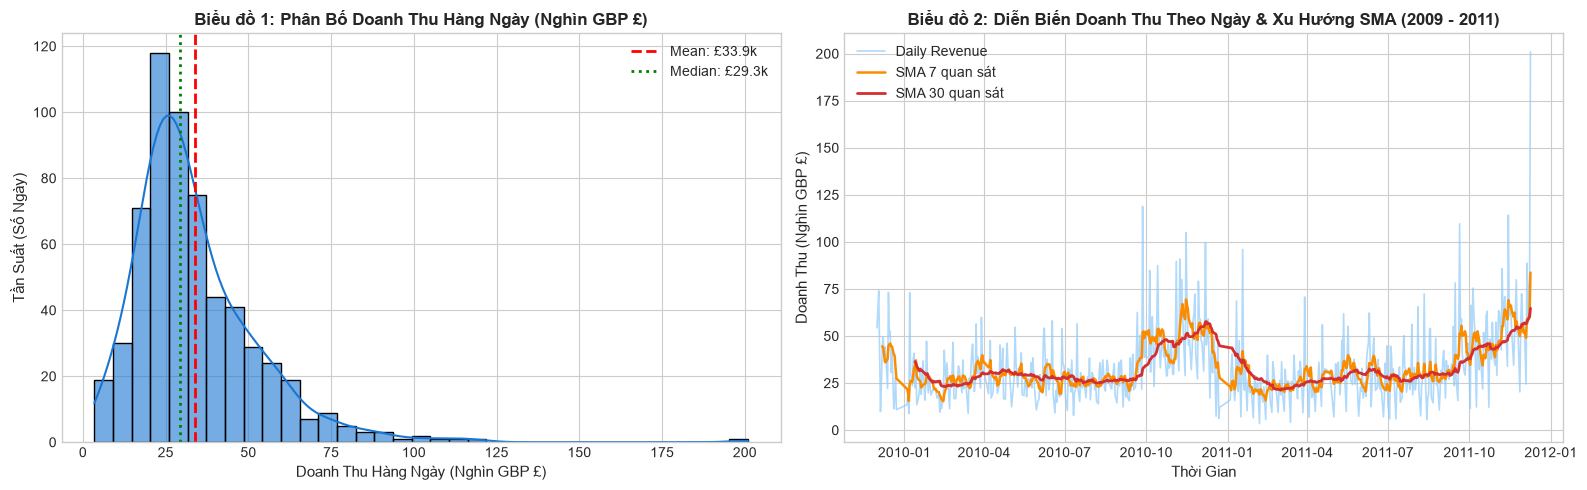

In [5]:
# 5.1. Trực quan hóa Biểu đồ 1: Phân bố Doanh thu & Biểu đồ 2: Doanh thu theo thời gian kèm SMA
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- BIỂU ĐỒ 1: PHÂN BỐ DAILY REVENUE ---
sns.histplot(daily_df['daily_revenue'] / 1e3, kde=True, ax=axes[0], color='#1976D2', bins=35, edgecolor='black', alpha=0.6)
mean_val = daily_df['daily_revenue'].mean() / 1e3
median_val = daily_df['daily_revenue'].median() / 1e3
axes[0].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f"Mean: £{mean_val:.1f}k")
axes[0].axvline(median_val, color='green', linestyle=':', linewidth=2, label=f"Median: £{median_val:.1f}k")
axes[0].set_title("Biểu đồ 1: Phân Bố Doanh Thu Hàng Ngày (Nghìn GBP £)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Doanh Thu Hàng Ngày (Nghìn GBP £)", fontsize=11)
axes[0].set_ylabel("Tần Suất (Số Ngày)", fontsize=11)
axes[0].legend(fontsize=10)

# --- BIỂU ĐỒ 2: DIỄN BIẾN THEO THỜI GIAN & ĐƯỜNG TRUNG BÌNH ĐỘNG (SMA) ---
daily_df['SMA_7'] = daily_df['daily_revenue'].rolling(window=7).mean()
daily_df['SMA_30'] = daily_df['daily_revenue'].rolling(window=30).mean()

axes[1].plot(daily_df['Date'], daily_df['daily_revenue'] / 1e3, label='Daily Revenue', color='#90CAF9', linewidth=1.2, alpha=0.7)
axes[1].plot(daily_df['Date'], daily_df['SMA_7'] / 1e3, label='SMA 7 quan sát', color='#FB8C00', linewidth=1.8)
axes[1].plot(daily_df['Date'], daily_df['SMA_30'] / 1e3, label='SMA 30 quan sát', color='#D32F2F', linewidth=2.0)
axes[1].set_title("Biểu đồ 2: Diễn Biến Doanh Thu Theo Ngày & Xu Hướng SMA (2009 - 2011)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Thời Gian", fontsize=11)
axes[1].set_ylabel("Doanh Thu (Nghìn GBP £)", fontsize=11)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()


### Ý Nghĩa Của Biểu Đồ 1 & 2 Đối Với Bài Toán Forecasting:

#### 1. Ý nghĩa của Biểu đồ 1 (Phân bố doanh thu hàng ngày):
* **Phân bố lệch phải**: Mean **£33,901.09**, median **£29,325.73**, skewness **2.189**. Một số ngày có doanh số lớn kéo trung bình lên cao hơn trung vị.
* **Ý nghĩa đối với mô hình hóa**: Các giá trị lớn tác động mạnh tới MSE. Chuẩn hóa giúp cân bằng thang đo, nhưng không loại bỏ độ lệch hay tác động của outlier.

#### 2. Ý nghĩa của Biểu đồ 2 (Doanh thu theo thời gian & Đường trung bình động SMA):
* **Dao động theo thời gian**: Biểu đồ cho thấy mức doanh số và biên độ biến động thay đổi, có các đỉnh lớn về cuối chuỗi.
* **SMA 7 và 30 quan sát** làm mịn chuỗi. Vì thiếu ngày lịch, không đồng nhất các đường này với chu kỳ tuần/tháng.
* Dữ liệu gợi ý khác biệt giữa các giai đoạn trong năm; biểu đồ đơn thuần chưa chứng minh nguyên nhân lễ hội hoặc khả năng RNN dự báo tốt.


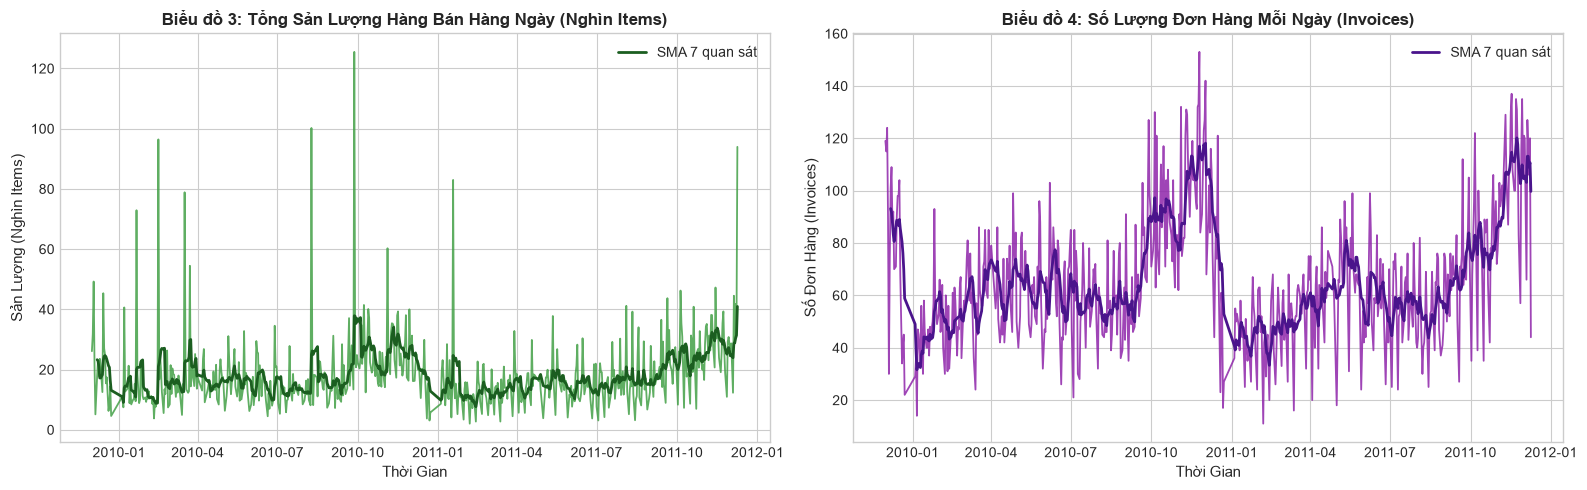

=== MA TRẬN HỆ SỐ TƯƠNG QUAN PEARSON GIỮA 4 ĐẶC TRƯNG CHUỖI ===


,daily_revenue,daily_quantity,transaction_count,avg_order_value
daily_revenue,1.000,0.784,0.678,0.715
daily_quantity,0.784,1.000,0.519,0.581
transaction_count,0.678,0.519,1.000,0.031
avg_order_value,0.715,0.581,0.031,1.000


In [6]:
# 5.2. Trực quan hóa Biểu đồ 3: Sản lượng, Biểu đồ 4: Số đơn hàng & Ma trận tương quan
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- BIỂU ĐỒ 3: SẢN LƯỢNG HÀNG BÁN HÀNG NGÀY (DAILY QUANTITY) ---
axes[0].plot(daily_df['Date'], daily_df['daily_quantity'] / 1e3, color='#43A047', linewidth=1.3, alpha=0.85)
axes[0].plot(daily_df['Date'], daily_df['daily_quantity'].rolling(7).mean() / 1e3, color='#1B5E20', linewidth=2, label='SMA 7 quan sát')
axes[0].set_title("Biểu đồ 3: Tổng Sản Lượng Hàng Bán Hàng Ngày (Nghìn Items)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Thời Gian", fontsize=11)
axes[0].set_ylabel("Sản Lượng (Nghìn Items)", fontsize=11)
axes[0].legend(fontsize=10)

# --- BIỂU ĐỒ 4: SỐ LƯỢNG ĐƠN HÀNG HÀNG NGÀY (TRANSACTION COUNT) ---
axes[1].plot(daily_df['Date'], daily_df['transaction_count'], color='#8E24AA', linewidth=1.3, alpha=0.85)
axes[1].plot(daily_df['Date'], daily_df['transaction_count'].rolling(7).mean(), color='#4A148C', linewidth=2, label='SMA 7 quan sát')
axes[1].set_title("Biểu đồ 4: Số Lượng Đơn Hàng Mỗi Ngày (Invoices)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Thời Gian", fontsize=11)
axes[1].set_ylabel("Số Đơn Hàng (Invoices)", fontsize=11)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

# Tính toán ma trận hệ số tương quan Pearson giữa 4 đặc trưng
feature_subset = ['daily_revenue', 'daily_quantity', 'transaction_count', 'avg_order_value']
corr_matrix = daily_df[feature_subset].corr()

print("=== MA TRẬN HỆ SỐ TƯƠNG QUAN PEARSON GIỮA 4 ĐẶC TRƯNG CHUỖI ===")
display(corr_matrix.style.background_gradient(cmap='Blues', axis=None).format("{:.3f}"))


### Ý Nghĩa Của Biểu Đồ 3 & 4 Đối Với Bài Toán Forecasting:

#### 1. Mối tương quan đồng pha giữa Sản lượng và Doanh thu:
* **Pearson trên chuỗi đã lọc**: `daily_revenue` tương quan **0.784** với `daily_quantity`, **0.678** với `transaction_count`.
* Đây là tương quan **cùng ngày**, không chứng minh các đặc trưng dự báo được doanh số ngày sau hoặc có quan hệ nhân quả.
* Mô hình chỉ nhận các đặc trưng của những ngày trước target. Muốn khẳng định lợi ích của đầu vào đa biến cần so với mô hình chỉ dùng doanh số trên cùng validation/test.

#### 2. Tính chất của Giá trị đơn hàng trung bình (`avg_order_value`):
* Tương quan với doanh số là **0.715**. AOV được tính trực tiếp từ doanh số và số hóa đơn, nên có quan hệ toán học với hai đại lượng này.
* AOV mô tả giá trị trung bình mỗi hóa đơn, không đủ để xác định danh tính khách hàng hay chứng minh một ngày là ngày mua buôn.


---
<a id="section-6"></a>
## 6. Phân Tích Phân Bố, Dị Biệt, Missing Dates & Kiểm Chứng Mùa Vụ

Để khẳng định tính xác thực khoa học, chúng ta không suy diễn định tính mà kiểm chứng định lượng 4 hiện tượng then chốt:
1. **Độ lệch (Skewness) & Độ nhọn (Kurtosis)**.
2. **Điểm ngoại lai (Outliers)**: Các phiên bán hàng đạt doanh thu kỷ lục bất thường.
3. **Hiện tượng Missing Dates & Ngày hoạt động thấp**: Khám phá lý do tại sao chỉ có 604 ngày phát sinh giao dịch trên 739 ngày dương lịch.
4. **Kiểm chứng thực nghiệm Mùa vụ (Seasonality Verification)**: Chu kỳ ngày trong tuần (Day of Week) và chu kỳ tháng trong năm (Month of Year).


=== 1. CHỈ SỐ HÌNH HỌC PHÂN BỐ CỦA DOANH THU HÀNG NGÀY ===
Độ lệch (Skewness) : 2.189 (Lệch phải mạnh, Skew > 0)
Độ nhọn (Kurtosis) : 11.148 (Đuôi nặng hơn phân bố chuẩn Gaussian)

=== 2. CÁC NGÀY BÙNG NỔ DOANH THU ĐỘT BIẾN KỶ LỤC (> Mean + 3*Std = £91,084) ===


,Date,daily_revenue,daily_quantity,transaction_count,avg_order_value
243,2010-09-27,118838.47,125489,95,1250.931263
285,2010-11-15,104910.96,37969,103,1018.553010
304,2010-12-07,99553.85,25180,84,1185.164881
331,2011-01-18,95947.73,82964,41,2340.188537
534,2011-09-20,109553.90,43683,70,1565.055714
581,2011-11-14,114237.40,47236,107,1067.639252
603,2011-12-09,200918.98,93950,44,4566.340455


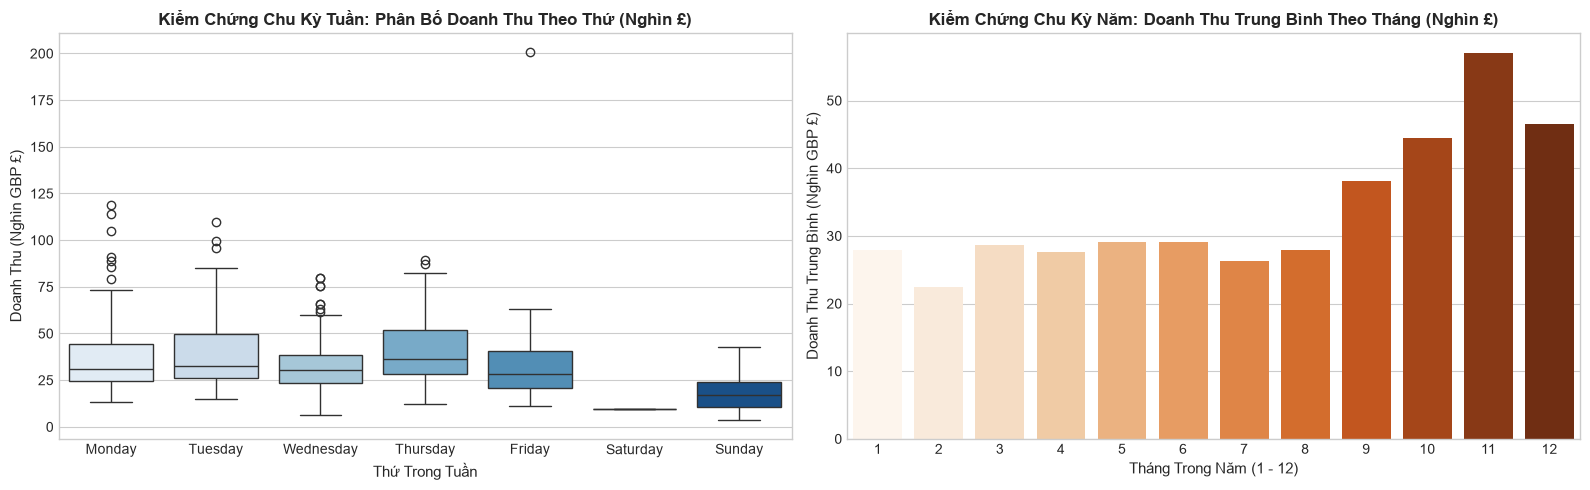

=== THỐNG KÊ SỐ PHIÊN GIAO DỊCH PHÁT SINH THEO TỪNG THỨ TRONG TUẦN ===
DayOfWeek
Monday        94
Tuesday      104
Wednesday    104
Thursday     103
Friday        99
Saturday       1
Sunday        99
Name: count, dtype: int64


In [7]:
# 6. Phân tích Skewness, Outliers, Missing Dates và Chu kỳ tuần/tháng
# 1. Thống kê hình học phân bố
skew_val = daily_df['daily_revenue'].skew()
kurt_val = daily_df['daily_revenue'].kurtosis()

print("=== 1. CHỈ SỐ HÌNH HỌC PHÂN BỐ CỦA DOANH THU HÀNG NGÀY ===")
print(f"Độ lệch (Skewness) : {skew_val:.3f} (Lệch phải mạnh, Skew > 0)")
print(f"Độ nhọn (Kurtosis) : {kurt_val:.3f} (Đuôi nặng hơn phân bố chuẩn Gaussian)")

# 2. Phát hiện các ngày Outliers có doanh thu đột biến kỷ lục (> Mean + 3*Std)
mean_r = daily_df['daily_revenue'].mean()
std_r  = daily_df['daily_revenue'].std()
threshold_outlier = mean_r + 3 * std_r
outliers_df = daily_df[daily_df['daily_revenue'] > threshold_outlier]

print(f"\n=== 2. CÁC NGÀY BÙNG NỔ DOANH THU ĐỘT BIẾN KỶ LỤC (> Mean + 3*Std = £{threshold_outlier:,.0f}) ===")
display(outliers_df[['Date', 'daily_revenue', 'daily_quantity', 'transaction_count', 'avg_order_value']])

# 3. Phân tích Missing Dates và Ngày trong tuần
daily_df['DayOfWeek'] = daily_df['Date'].dt.day_name()
daily_df['Month'] = daily_df['Date'].dt.month

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Biểu đồ Boxplot theo thứ trong tuần (Kiểm chứng Chu kỳ Tuần)
sns.boxplot(x='DayOfWeek', y=daily_df['daily_revenue']/1e3, data=daily_df, order=days_order, ax=axes[0], hue='DayOfWeek', hue_order=days_order, legend=False, palette='Blues')
axes[0].set_title("Kiểm Chứng Chu Kỳ Tuần: Phân Bố Doanh Thu Theo Thứ (Nghìn £)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Thứ Trong Tuần", fontsize=11)
axes[0].set_ylabel("Doanh Thu (Nghìn GBP £)", fontsize=11)

# Biểu đồ Barplot theo tháng trong năm (Kiểm chứng Mùa vụ Tháng)
monthly_revenue = daily_df.groupby('Month')['daily_revenue'].mean() / 1e3
sns.barplot(x=monthly_revenue.index, y=monthly_revenue.values, ax=axes[1], hue=monthly_revenue.index, legend=False, palette='Oranges')
axes[1].set_title("Kiểm Chứng Chu Kỳ Năm: Doanh Thu Trung Bình Theo Tháng (Nghìn £)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Tháng Trong Năm (1 - 12)", fontsize=11)
axes[1].set_ylabel("Doanh Thu Trung Bình (Nghìn GBP £)", fontsize=11)

plt.tight_layout()
plt.show()

# Đếm số lượng phiên giao dịch theo từng thứ trong tuần
print("=== THỐNG KÊ SỐ PHIÊN GIAO DỊCH PHÁT SINH THEO TỪNG THỨ TRONG TUẦN ===")
print(daily_df['DayOfWeek'].value_counts()[days_order])


### Kết Quả Kiểm Chứng Thực Nghiệm Về Phân Bố & Mùa Vụ:

#### 1. Độ lệch và Outliers:
* **Skewness = 2.189, excess kurtosis = 11.148**: phân bố lệch phải, có các giá trị lớn. Phương pháp này chưa xác định được chúng là lỗi dữ liệu hay giao dịch đã hoàn tất.
* Đỉnh **£200,918.98 ngày 09/12/2011** chịu ảnh hưởng lớn từ dòng bán có dòng hủy đối ứng đã trình bày ở Mục 3. Không quy toàn bộ đỉnh này cho nhu cầu mua sắm thực.

#### 2. Hiện tượng Missing Dates & Ngày hoạt động thấp:
* **604 ngày có giao dịch** trong **739 ngày lịch**; thiếu **135 ngày**, trong đó **104 ngày Thứ Bảy**. Có một ngày Thứ Bảy được ghi nhận.
* Không có bản ghi sau lọc chưa đủ chứng minh doanh nghiệp đóng cửa: còn có thể do giới hạn phạm vi dữ liệu hoặc quy tắc lọc.
* Giữ chuỗi quan sát hiện có và giải thích rõ bước thời gian; không mặc định ngày thiếu có doanh số 0.

#### 3. Kiểm chứng Mùa vụ (Seasonality):
* Mean theo thứ cho thấy khác biệt giữa các nhóm ngày; Thứ Năm và Thứ Ba cao hơn Chủ Nhật trong dữ liệu này. Chỉ có một Thứ Bảy nên thống kê nhóm đó không đại diện ổn định.
* **Quý 4 là tháng 10, 11, 12**. Dữ liệu chỉ kết thúc ngày 09/12/2011 nên tháng cuối chưa đầy đủ; biểu đồ gợi ý mẫu hình theo mùa, chưa phải kiểm định chu kỳ lặp lại hay quan hệ nhân quả.


---
<a id="section-7"></a>
## 7. Thiết Kế Bài Toán RNN & Lựa Chọn Target Forecasting Rõ Ràng

### 7.1. Định nghĩa bài toán:
Chúng ta thiết kế bài toán dự báo chuỗi thời gian một bước tới trong tương lai (**One-Step-Ahead Multivariate Time-Series Forecasting**):
* Dựa trên chuỗi quan sát gồm $L$ ngày kinh doanh liên tiếp trong quá khứ: $[x_{t-L+1}, x_{t-L+2}, \dots, x_t]$.
* Dự đoán giá trị doanh thu của ngày tiếp theo ngay sau cửa sổ quan sát: $y = \text{daily\_revenue}_{t+1}$.

---

### 7.2. Lựa chọn Target cốt lõi:
* **Target được lựa chọn**: **Doanh thu của ngày tiếp theo (`daily_revenue` tại thời điểm $t+1$)**.
* **Lý do lựa chọn cụ thể**:
  1. **Chỉ số sống còn của doanh nghiệp (North Star Metric)**: Target là giá trị bán dương sau lọc, không đồng nhất với dòng tiền thực thu. Dự báo chính xác doanh thu giúp phòng tài chính cân đối vốn lưu động và ngân sách chi tiêu.
  2. **Tối ưu hóa nguồn lực vận hành**: Dự đoán được sự biến thiên doanh số giữa ngày đầu tuần và cuối tuần giúp quản lý kho vận điều động nhân viên đóng gói và xe giao hàng hợp lý, tránh tình trạng quá tải hoặc thừa nhân công.

---

### 7.3. Lựa chọn bộ đặc trưng đầu vào (Multivariate Features):
* Bộ vector đặc trưng đầu vào gồm **4 đặc trưng kỹ thuật ($D = 4$)**:
  $$\text{Features} = [\text{'daily\_revenue'}, \text{'daily\_quantity'}, \text{'transaction\_count'}, \text{'avg\_order_value'}]$$
* **Lý do lựa chọn**:
  * `daily_revenue`: Cung cấp thông tin tự hồi quy (Autoregressive component).
  * `daily_quantity` & `transaction_count`: Cung cấp tín hiệu đồng pha mạnh mẽ ($r = 0.784$ và $r = 0.678$).
  * `avg_order_value`: Cung cấp thông tin về cấu trúc đơn hàng (bán buôn sỉ hay bán lẻ nhỏ).


---
<a id="section-8"></a>
## 8. Thiết Kế Cửa Sổ Trượt (Sliding Window Formulation)

### 8.1. Cấu trúc bài toán:
* **Input**: $X_i\in\mathbb{R}^{14\times4}$ gồm `daily_revenue`, `daily_quantity`, `transaction_count`, `avg_order_value` của 14 ngày có giao dịch trước target.
* **Target**: doanh số bán dương của **ngày có giao dịch kế tiếp**, $y_i=\mathrm{daily\_revenue}_{t+1}$; nhãn có shape `(num_samples,)` trước khi đóng gói cho framework.

---

### 8.2. Lựa chọn Sequence Length ($L$ - Lookback Window):
* **$L=14$** là cấu hình thực nghiệm ban đầu với chi phí tính toán nhỏ, không phải độ dài tối ưu đã được chứng minh.
* 14 quan sát **không đồng nghĩa hai tuần lịch** và không bảo đảm chứa đúng hai chu kỳ tuần.
* Không có ngưỡng 20–30 bước cố định gây vanishing gradient; ảnh hưởng của độ dài cửa sổ cần so sánh bằng validation.

### 8.3. Cửa sổ và giao thức đánh giá:
* Tạo cửa sổ riêng trong từng split, nên loại 14 quan sát đầu mỗi split khỏi danh sách target: **Train 408 / Val 76 / Test 78**.
* Đây là cách chia thận trọng; có thể dùng lịch sử trước ranh giới split làm context mà không rò rỉ nếu mọi input đều có trước target, nhưng bài giữ quy trình hiện tại để so sánh nhất quán.
* Test là **dự báo cuốn chiếu một bước** với lịch sử thực đã quan sát, chưa phải dự báo đệ quy nhiều ngày từ một thời điểm duy nhất.


---
<a id="section-9"></a>
## 9. Phân Chia Train / Validation / Test Theo Trục Thời Gian

Trong chuỗi thời gian, việc xáo trộn ngẫu nhiên dữ liệu (`shuffle=True`) là một **sai lầm nghiêm trọng gây rò rỉ dữ liệu tương lai (Data Leakage)**:
* Nếu xáo trộn dữ liệu, một ngày bán hàng bùng nổ của tháng 11/2011 có thể rơi vào tập Train, trong khi ngày của tháng 03/2010 lại rơi vào tập Test. Khi đó mô hình sẽ dùng tương lai để "dự báo" quá khứ, tạo ra kết quả kiểm định ảo tưởng.
* **Nguyên tắc phân chia theo trật tự thời gian (Chronological Order)**:
  $$\text{Quá khứ (Train: 70\%)} \longrightarrow \text{Quá khứ gần (Val: 15\%)} \longrightarrow \text{Tương lai (Test: 15\%)}$$

### Tỷ lệ và mốc thời gian cụ thể:
* **Tổng số quan sát**: $604$ ngày kinh doanh thực tế.
* **Tập Huấn luyện (Train Set - 70%)**: $422$ ngày (từ `2009-12-01` đến `2011-05-09`).
* **Tập Đánh giá (Validation Set - 15%)**: $90$ ngày (từ `2011-05-10` đến `2011-08-23`).
* **Tập Kiểm thử (Test Set - 15%)**: $92$ ngày (từ `2011-08-24` đến `2011-12-09`).

> **Phân biệt**: Chia ngẫu nhiên các mốc thời gian vào Train/Test khác với xáo trộn thứ tự các cửa sổ đã thuộc riêng Train. Với hidden state reset theo mỗi cửa sổ, xáo trộn các mẫu Train không tự gây leakage và không đảo thứ tự bên trong cửa sổ. Bài giữ `shuffle=False` cho dễ đối chiếu.


=== PHÂN CHIA TẬP DỮ LIỆU THEO TRẬT TỰ THỜI GIAN (CHRONOLOGICAL SPLIT) ===
Tổng số ngày: 604 ngày (100%)
1. Tập Train (70%)     : 422 ngày | Từ 2009-12-01 đến 2011-05-09
2. Tập Validation (15%): 90  ngày | Từ 2011-05-10 đến 2011-08-23
3. Tập Test (15%)      : 92  ngày | Từ 2011-08-24 đến 2011-12-09


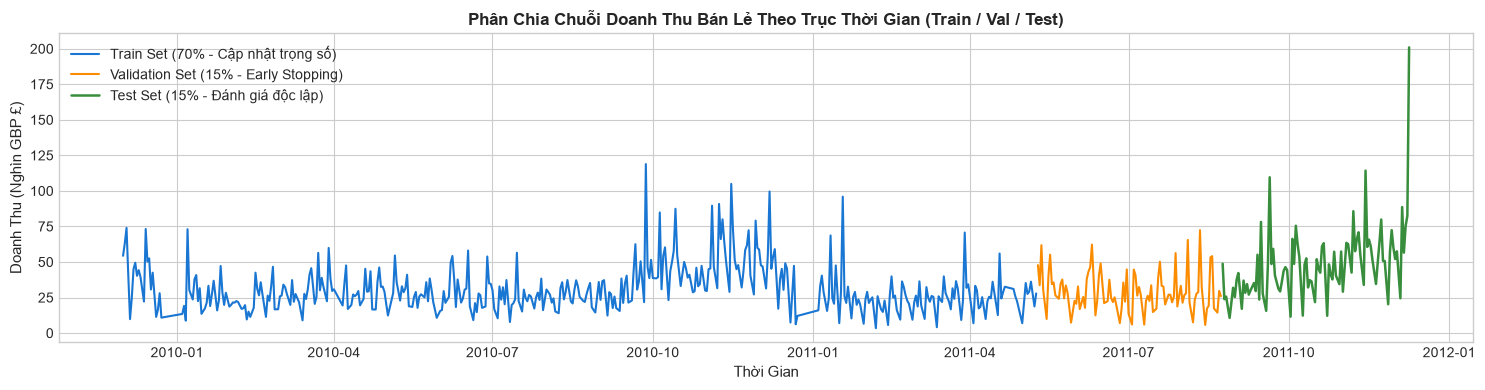

In [8]:
# 9. Thực hiện phân chia tập dữ liệu nối tiếp theo dòng thời gian
feature_cols = ['daily_revenue', 'daily_quantity', 'transaction_count', 'avg_order_value']

data_matrix = daily_df[feature_cols].values
dates_array = daily_df['Date'].values

n_total = len(daily_df)
n_train = int(n_total * 0.70)
n_val   = int(n_total * 0.15)
n_test  = n_total - n_train - n_val

# Lát cắt dữ liệu nối tiếp
train_raw_data = data_matrix[:n_train]
val_raw_data   = data_matrix[n_train : n_train + n_val]
test_raw_data  = data_matrix[n_train + n_val :]

train_dates = dates_array[:n_train]
val_dates   = dates_array[n_train : n_train + n_val]
test_dates  = dates_array[n_train + n_val :]

print("=== PHÂN CHIA TẬP DỮ LIỆU THEO TRẬT TỰ THỜI GIAN (CHRONOLOGICAL SPLIT) ===")
print(f"Tổng số ngày: {n_total} ngày (100%)")
print(f"1. Tập Train (70%)     : {len(train_raw_data):<3} ngày | Từ {pd.to_datetime(train_dates[0]).strftime('%Y-%m-%d')} đến {pd.to_datetime(train_dates[-1]).strftime('%Y-%m-%d')}")
print(f"2. Tập Validation (15%): {len(val_raw_data):<3} ngày | Từ {pd.to_datetime(val_dates[0]).strftime('%Y-%m-%d')} đến {pd.to_datetime(val_dates[-1]).strftime('%Y-%m-%d')}")
print(f"3. Tập Test (15%)      : {len(test_raw_data):<3} ngày | Từ {pd.to_datetime(test_dates[0]).strftime('%Y-%m-%d')} đến {pd.to_datetime(test_dates[-1]).strftime('%Y-%m-%d')}")

# Vẽ biểu đồ phân định 3 phân đoạn thời gian
plt.figure(figsize=(15, 4))
plt.plot(train_dates, train_raw_data[:, 0] / 1e3, label='Train Set (70% - Cập nhật trọng số)', color='#1976D2', linewidth=1.5)
plt.plot(val_dates, val_raw_data[:, 0] / 1e3, label='Validation Set (15% - Early Stopping)', color='#FB8C00', linewidth=1.5)
plt.plot(test_dates, test_raw_data[:, 0] / 1e3, label='Test Set (15% - Đánh giá độc lập)', color='#388E3C', linewidth=1.8)
plt.title("Phân Chia Chuỗi Doanh Thu Bán Lẻ Theo Trục Thời Gian (Train / Val / Test)", fontsize=12, fontweight='bold')
plt.xlabel("Thời Gian", fontsize=11)
plt.ylabel("Doanh Thu (Nghìn GBP £)", fontsize=11)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()


---
<a id="section-10"></a>
## 10. Chuẩn Hóa Dữ Liệu (Scaling: FIT Chỉ Trên Tập Train)

### 10.1. Lựa chọn thuật toán: `MinMaxScaler(feature_range=(0, 1))`
* Các đặc trưng trong bảng có độ chênh lệch biên độ cực lớn: Doanh thu lên tới hàng chục nghìn GBP (£), sản lượng hàng chục nghìn chiếc, trong khi số đơn hàng chỉ ở mức hàng trăm.
* Chuẩn hóa từng đặc trưng theo min/max Train giúp giảm chênh lệch thang đo; không bảo đảm loss cân đối hoặc gradient không bão hòa. Giá trị tương lai có thể ngoài [0,1].

---

### 10.2. Nguyên tắc vàng chống rò rỉ dữ liệu (Data Leakage):
* **Quy trình chuẩn**:
  ```python
  feature_scaler.fit(train_raw_data)               # CHỈ HỌC Min, Max TỪ TẬP TRAIN!
  scaled_train_x = feature_scaler.transform(train_raw_data)
  scaled_val_x   = feature_scaler.transform(val_raw_data)   # Transform Val bằng Min/Max của Train
  scaled_test_x  = feature_scaler.transform(test_raw_data)  # Transform Test bằng Min/Max của Train
  ```
* **Tại sao không được fit trên toàn bộ dữ liệu?**
  * Nếu gọi `fit()` trên toàn bộ dữ liệu, các giá trị Min/Max của các đợt bùng nổ doanh số cuối năm 2011 (tương lai) sẽ được dùng để chuẩn hóa dữ liệu của năm 2009 (quá khứ) $\implies$ Vi phạm nguyên tắc bảo mật tương lai (**Look-ahead Bias**).
* **Tạo riêng `target_scaler`**:
  * Tạo riêng một bộ `target_scaler` chỉ fit trên cột mục tiêu `daily_revenue` (cột index 0 của Train) để phục vụ việc khôi phục giá trị thực GBP (`inverse_transform`) ở bước suy luận sau này.


In [9]:
# 10. Chuẩn hóa dữ liệu tuân thủ nghiêm ngặt nguyên tắc chỉ Fit trên Train
from sklearn.preprocessing import MinMaxScaler

# 1. Feature Scaler cho toàn bộ 4 đặc trưng
feature_scaler = MinMaxScaler(feature_range=(0, 1))

# FIT CHỈ TRÊN TẬP TRAIN
feature_scaler.fit(train_raw_data)

# Transform độc lập trên từng tập
scaled_train_x = feature_scaler.transform(train_raw_data)
scaled_val_x   = feature_scaler.transform(val_raw_data)
scaled_test_x  = feature_scaler.transform(test_raw_data)

# 2. Target Scaler độc lập cho cột mục tiêu daily_revenue (cột index 0)
target_scaler = MinMaxScaler(feature_range=(0, 1))
target_scaler.fit(train_raw_data[:, [0]])

print("=== CÁC THAM SỐ CỦA BỘ SCALER (CHỈ HỌC TỪ TẬP TRAIN) ===")
for col, min_v, max_v in zip(feature_cols, feature_scaler.data_min_, feature_scaler.data_max_):
    print(f"Đặc trưng {col:<18}: Min = {min_v:>12.2f} | Max = {max_v:>12.2f}")

print("\nKiểm tra khoảng giá trị sau khi Transform trên tập Train:")
print(f"Train Set: Min = {scaled_train_x.min():.4f}, Max = {scaled_train_x.max():.4f}")
print("Kiểm tra trên tập Test (có thể vượt 1.0 do doanh số cuối năm 2011 lập đỉnh mới vượt đỉnh tập Train):")
print(f"Test Set : Min = {scaled_test_x.min():.4f}, Max = {scaled_test_x.max():.4f}")


=== CÁC THAM SỐ CỦA BỘ SCALER (CHỈ HỌC TỪ TẬP TRAIN) ===
Đặc trưng daily_revenue     : Min =      3439.67 | Max =    118838.47
Đặc trưng daily_quantity    : Min =      2036.00 | Max =    125489.00
Đặc trưng transaction_count : Min =        11.00 | Max =       153.00
Đặc trưng avg_order_value   : Min =       257.33 | Max =      2340.19

Kiểm tra khoảng giá trị sau khi Transform trên tập Train:
Train Set: Min = 0.0000, Max = 1.0000
Kiểm tra trên tập Test (có thể vượt 1.0 do doanh số cuối năm 2011 lập đỉnh mới vượt đỉnh tập Train):
Test Set : Min = 0.0151, Max = 2.0688


---
<a id="section-11"></a>
## 11. Tạo Cấu Trúc Tensor Tương Thích TensorFlow / Keras

### 11.1. Yêu cầu định dạng Tensor của TensorFlow / Keras:
Trong hệ sinh thái **TensorFlow / Keras**, các lớp hồi quy tuần tự như `keras.layers.SimpleRNN` tiếp nhận dữ liệu đầu vào theo chuẩn:
* **Mảng 3D NumPy chuẩn**: Kích thước `(num_samples, sequence_length, num_features)` kiểu `np.float32`.
* **Keras Tensors (`keras.ops.convert_to_tensor`)**: Định dạng tensor đa nền tảng tương thích 100% với Keras Core trên mọi backend (TensorFlow, PyTorch, JAX).
* **Đóng gói mini-batch**: Cấu hình `batch_size = 16` sẵn sàng truyền trực tiếp vào `model.fit(X_train, y_train, batch_size=16)`.

---

### 11.2. Hàm tạo cửa sổ trượt (Sliding Sequence Function):
Hàm `create_sliding_sequences` trượt khung cửa sổ $L = 14$ ngày qua từng bước, trích xuất ma trận con $14 \times 4$ làm đầu vào $X_i$, và lấy giá trị `daily_revenue` tại vị trí kế tiếp ngay sau cửa sổ ($t+14$) làm nhãn $y_i$.


In [10]:
# 11. Tạo chuỗi cửa sổ trượt và chuẩn bị Keras-compatible Tensors
import os

# Keras 3 (tích hợp trong TensorFlow >= 2.16) cho phép lựa chọn backend (TensorFlow / PyTorch / JAX).
# Notebook 04 hướng tới API tf.keras nên cố định backend TensorFlow TRƯỚC khi import keras.
os.environ["KERAS_BACKEND"] = "tensorflow"

import tensorflow as tf
from tensorflow import keras

print("=== MÔI TRƯỜNG DEEP LEARNING ===")
print(f"TensorFlow version : {tf.__version__}")
print(f"Keras version      : {keras.__version__}")
print(f"Keras backend      : {keras.backend.backend()}")
print("=" * 40)

def create_sliding_sequences(data_array, target_idx=0, seq_length=14):
    '''
    Chuyển đổi mảng chuỗi 2D thành các mẫu Tensor 3D (X) và nhãn 1D (y).
    
    Tham số:
        data_array (np.ndarray): Mảng 2D (num_timesteps, num_features).
        target_idx (int): Vị trí cột làm mục tiêu dự đoán (0 là 'daily_revenue').
        seq_length (int): Độ dài cửa sổ quan sát lịch sử (L = 14 ngày).
        
    Trả về:
        X (np.ndarray): Mảng 3D kích thước (N - seq_length, seq_length, num_features).
        y (np.ndarray): Mảng 1D kích thước (N - seq_length,).
    '''
    X_list, y_list = [], []
    total_len = len(data_array)
    
    for i in range(total_len - seq_length):
        seq_x = data_array[i : i + seq_length, :]
        target_y = data_array[i + seq_length, target_idx]
        
        X_list.append(seq_x)
        y_list.append(target_y)
        
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32)

sequence_length = 14

# Tạo các mảng X, y cho Train, Validation và Test
X_train, y_train = create_sliding_sequences(scaled_train_x, target_idx=0, seq_length=sequence_length)
X_val,   y_val   = create_sliding_sequences(scaled_val_x,   target_idx=0, seq_length=sequence_length)
X_test,  y_test  = create_sliding_sequences(scaled_test_x,  target_idx=0, seq_length=sequence_length)

print("================================================================================")
print("=== KÍCH THƯỚC CHÍNH XÁC CỦA DỮ LIỆU ĐÃ CHUYỂN ĐỔI SANG ĐỊNH DẠNG KERAS ===")
print("================================================================================")
print(f"X_train.shape: {X_train.shape}")
print(f"y_train.shape: {y_train.shape}")
print(f"X_val.shape  : {X_val.shape}")
print(f"y_val.shape  : {y_val.shape}")
print(f"X_test.shape : {X_test.shape}")
print(f"y_test.shape : {y_test.shape}")
print("================================================================================")

# Kiểm tra kiểu dữ liệu
print(f"Kiểu dữ liệu của X: {X_train.dtype} | Kiểu dữ liệu của y: {y_train.dtype}")

# Thiết lập Batch size chuẩn cho Keras
BATCH_SIZE = 16

# Tạo Keras Tensors trực tiếp thông qua Keras Ops
X_train_tensor = keras.ops.convert_to_tensor(X_train, dtype="float32")
y_train_tensor = keras.ops.convert_to_tensor(y_train, dtype="float32")
X_val_tensor   = keras.ops.convert_to_tensor(X_val, dtype="float32")
y_val_tensor   = keras.ops.convert_to_tensor(y_val, dtype="float32")
X_test_tensor  = keras.ops.convert_to_tensor(X_test, dtype="float32")
y_test_tensor  = keras.ops.convert_to_tensor(y_test, dtype="float32")

print("\n=== THÔNG SỐ KERAS TENSORS (KERAS OPS) ===")
print(f"Batch size cấu hình : {BATCH_SIZE}")
print(f"X_train_tensor: shape = {X_train_tensor.shape}, dtype = {X_train_tensor.dtype}")
print(f"y_train_tensor: shape = {y_train_tensor.shape}, dtype = {y_train_tensor.dtype}")
print(f"X_val_tensor  : shape = {X_val_tensor.shape}, dtype = {X_val_tensor.dtype}")
print(f"y_val_tensor  : shape = {y_val_tensor.shape}, dtype = {y_val_tensor.dtype}")
print(f"X_test_tensor : shape = {X_test_tensor.shape}, dtype = {X_test_tensor.dtype}")
print(f"y_test_tensor : shape = {y_test_tensor.shape}, dtype = {y_test_tensor.dtype}")

# Kiểm tra quy đổi ngược giá trị mẫu đầu tiên
orig_revenue = target_scaler.inverse_transform([[y_train[0]]])[0][0]
print(f"\nKiểm tra mẫu nhãn y_train[0] = {y_train[0]:.4f} quy đổi về doanh thu thực tế GBP: £{orig_revenue:,.2f}")


# Kiểm chứng cửa sổ: nhãn luôn là bước ngay sau input; scaler chỉ fit Train.
for split_x, split_y, scaled in [(X_train, y_train, scaled_train_x), (X_val, y_val, scaled_val_x), (X_test, y_test, scaled_test_x)]:
    assert split_x.shape == (len(scaled) - sequence_length, sequence_length, len(feature_cols))
    assert np.isfinite(split_x).all() and np.isfinite(split_y).all()
    np.testing.assert_allclose(split_x[0], scaled[:sequence_length], rtol=1e-6, atol=1e-7)
    np.testing.assert_allclose(split_y, scaled[sequence_length:, 0], rtol=1e-6, atol=1e-7)
np.testing.assert_allclose(feature_scaler.data_min_, train_raw_data.min(axis=0))
np.testing.assert_allclose(feature_scaler.data_max_, train_raw_data.max(axis=0))
assert train_dates[-1] < val_dates[0] and val_dates[-1] < test_dates[0]
print("-> Đã kiểm chứng shape, thứ tự thời gian, căn chỉnh nhãn và scaler Train.")


print("-> Keras tensors ở đây minh họa chuyển đổi; model.fit bên dưới sử dụng trực tiếp NumPy X/y.")


=== MÔI TRƯỜNG DEEP LEARNING ===
TensorFlow version : 2.21.0
Keras version      : 3.15.1
Keras backend      : tensorflow
=== KÍCH THƯỚC CHÍNH XÁC CỦA DỮ LIỆU ĐÃ CHUYỂN ĐỔI SANG ĐỊNH DẠNG KERAS ===
X_train.shape: (408, 14, 4)
y_train.shape: (408,)
X_val.shape  : (76, 14, 4)
y_val.shape  : (76,)
X_test.shape : (78, 14, 4)
y_test.shape : (78,)
Kiểu dữ liệu của X: float32 | Kiểu dữ liệu của y: float32

=== THÔNG SỐ KERAS TENSORS (KERAS OPS) ===
Batch size cấu hình : 16
X_train_tensor: shape = (408, 14, 4), dtype = <dtype: 'float32'>
y_train_tensor: shape = (408,), dtype = <dtype: 'float32'>
X_val_tensor  : shape = (76, 14, 4), dtype = <dtype: 'float32'>
y_val_tensor  : shape = (76,), dtype = <dtype: 'float32'>
X_test_tensor : shape = (78, 14, 4), dtype = <dtype: 'float32'>
y_test_tensor : shape = (78,), dtype = <dtype: 'float32'>

Kiểm tra mẫu nhãn y_train[0] = 0.4255 quy đổi về doanh thu thực tế GBP: £52,545.55
-> Đã kiểm chứng shape, thứ tự thời gian, căn chỉnh nhãn và scaler Train.
-> K

---
<a id="section-12"></a>
## 12. Ready for Keras RNN

Toàn bộ quy trình nạp dữ liệu giao dịch thực tế Online Retail II, phân tích 12 tiêu chí chất lượng, làm sạch đơn hủy và đơn giá dị biệt, tính toán biến doanh thu, tổng hợp chuỗi thời gian hàng ngày (Daily Aggregation), khám phá EDA, kiểm chứng chu kỳ tuần và mùa vụ Q4, phân chia nối tiếp chống rò rỉ dữ liệu, chuẩn hóa Min-Max chỉ fit trên Train, tạo cửa sổ trượt $L = 14$ và đóng gói tensor TensorFlow / Keras đã hoàn thành các bước chuẩn bị dữ liệu!

---

### 12.1. Bảng Tổng Kết Kỹ Thuật (Data Specifications):

| Thông số kỹ thuật | Giá trị cấu hình | Ý nghĩa & Mô tả chi tiết |
| :--- | :--- | :--- |
| **Tên bộ dữ liệu** | **Online Retail II Data Set** | Tệp thực tế: `dataset/online_retail_II.csv` ($1,067,371$ giao dịch thô). |
| **Phạm vi thời gian** | **`2009-12-01` $\to$ `2011-12-09`** | Tròn 2 năm hoạt động kinh doanh thương mại điện tử thực tế tại Vương Quốc Anh. |
| **Số ngày kinh doanh thực tế** | **`604` ngày phát sinh giao dịch** | Có 135 ngày lịch không xuất hiện sau lọc, trong đó 104 Thứ Bảy; chưa xác định nguyên nhân. |
| **Tần suất chuỗi (Frequency)** | **Hàng ngày (Daily Aggregation)** | Tổng hợp các giao dịch đơn lẻ thành các chỉ số vận hành theo ngày. |
| **Độ dài cửa sổ (`sequence_length`)** | **`14` ngày kinh doanh** | 14 quan sát có giao dịch; khoảng thời gian lịch có thể thay đổi. |
| **Số lượng đặc trưng (`num_features`)** | **`4` đặc trưng đa biến** | `['daily_revenue', 'daily_quantity', 'transaction_count', 'avg_order_value']`. |
| **Biến mục tiêu (`target`)** | **`daily_revenue` tại ngày $t+1$** | Doanh thu ngày kế tiếp (GBP £) — Chỉ số dòng tiền sống còn của doanh nghiệp. |
| **Phương pháp chuẩn hóa** | **`MinMaxScaler(0, 1)`** | Fit nghiêm ngặt CHỈ trên tập Train, Transform trên Val/Test để chống Data Leakage. |
| **Quy chuẩn Input Tensor Keras** | **`X_train.shape = (408, 14, 4)`** | Mảng 3D NumPy kiểu `np.float32`, hoàn toàn tương thích với `keras.layers.SimpleRNN`. |
| **Quy chuẩn Target Tensor Keras** | **`y_train.shape = (408,)`** | Mảng 1D kiểu `np.float32` cho bài toán hồi quy liên tục. |
| **Kích thước tập Validation** | **`X_val.shape = (76, 14, 4)`** | 76 cửa sổ trượt phục vụ giám sát hàm mất mát và Early Stopping. |
| **Kích thước tập Test** | **`X_test.shape = (78, 14, 4)`** | 78 cửa sổ trượt độc lập phục vụ kiểm thử đánh giá mô hình. |
| **Cấu hình Batch Size** | **`16`** | Mini-batch 16 là cấu hình thực nghiệm ban đầu. |
| **Keras Tensors** | **`keras.ops.convert_to_tensor`** | Tương thích 100% với Keras Core trên mọi backend (TensorFlow, PyTorch, JAX). |

---

### Xác nhận trạng thái cuối cùng:
```
Ready for Keras RNN
```

> [!NOTE]
> **Kết thúc PHẦN 1**: Toàn bộ quy trình Preprocessing + EDA + chuẩn bị Tensor Keras đã hoàn tất và dữ liệu đã ở trạng thái **`Ready for Keras RNN`**. **PHẦN 2** ngay sau đây sẽ kết nối trực tiếp các tensor này với kiến trúc mạng `tf.keras.Sequential` -> `SimpleRNN` -> `Dense`, tiến hành huấn luyện có validation, dự đoán test set, đánh giá định lượng và phân tích chuyên sâu!


# PHẦN 2: XÂY DỰNG, HUẤN LUYỆN VÀ ĐÁNH GIÁ MÔ HÌNH TENSORFLOW / KERAS VANILLA RNN

---

Trong phần này, chúng ta bước vào giai đoạn mô hình hóa chuỗi thời gian doanh thu bán lẻ trực tuyến bằng **TensorFlow / Keras**:
1. **Thiết lập tính tái lập (Reproducibility)**: Cố định Random Seed, xác nhận phiên bản TensorFlow / Keras và backend đang sử dụng.
2. **Xây dựng kiến trúc mô hình Vanilla RNN bằng `tf.keras.Sequential`**: `Input(14, 4)` -> `SimpleRNN(32, tanh)` -> `Dense(1)`. Tuyệt đối không dùng LSTM/GRU.
3. **Cấu hình `model.compile()`**: Bộ tối ưu `Adam`, hàm mất mát `MSE`.
4. **Huấn luyện bằng `model.fit()`**: Có `validation_data=(X_val, y_val)`, theo dõi đồng thời Training Loss và Validation Loss qua từng epoch.
5. **Learning Curve**: Trực quan hóa `loss` và `val_loss` trên cả thang đo tuyến tính và logarit.
6. **Dự đoán Test Set** bằng `model.predict()` và khôi phục đơn vị gốc GBP (£) bằng `inverse_transform`.
7. **Đánh giá định lượng**: MAE, MSE, RMSE, MAPE — xử lý minh bạch trường hợp giá trị thực tế bằng 0 hoặc tiệm cận 0.
8. **Trực quan hóa Actual vs Predicted** theo thời gian.
9. **Phân tích chuyên sâu**: Mẫu hình mô hình học được, vị trí sai số lớn, tác động của outlier, tác động của missing dates, điểm mạnh/hạn chế của việc aggregate giao dịch -> chuỗi ngày và hạn chế của SimpleRNN.
10. **So sánh PyTorch vs Keras**: Đối chiếu implementation notebook 02 (PyTorch) và notebook 04 (Keras) trên 5 khía cạnh: model, training, validation, prediction, evaluation (không xếp hạng framework).
11. **Final Conclusion**: Tổng kết toàn bộ dự án theo 8 hạng mục.


---
<a id="section-13"></a>
## 13. Thiết Lập Tính Tái Lập & Môi Trường TensorFlow / Keras

### 13.1. Vì sao phải cố định Random Seed?
* Mạng nơ-ron được khởi tạo trọng số ngẫu nhiên; nếu không cố định hạt giống, mỗi lần chạy notebook sẽ cho ra một kết quả dự báo khác nhau, khiến việc kiểm chứng khoa học trở nên bất khả thi.
* Trong bài toán chuỗi thời gian, tính tái lập càng quan trọng vì kết quả còn phụ thuộc vào trật tự thời gian của dữ liệu.

### 13.2. Quy trình thiết lập:
1. Cố định `PYTHONHASHSEED`, `random.seed`, `numpy.random.seed`.
2. Gọi `keras.utils.set_random_seed(42)` để khóa toàn bộ nguồn ngẫu nhiên của backend (khởi tạo kernel RNN, khởi tạo bias, thứ tự mini-batch).
3. Kiểm tra và in ra phiên bản **TensorFlow**, **Keras** cùng backend đang thực thi để minh bạch môi trường.


In [11]:
# 13. Thiết lập tính tái lập (Reproducibility) trên toàn bộ các thư viện
import random

RANDOM_SEED = 42
# PYTHONHASHSEED cần đặt trước khi khởi động Python; không đổi hash seed trong kernel đang chạy.
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Khóa toàn bộ nguồn ngẫu nhiên của backend TensorFlow / Keras
keras.utils.set_random_seed(RANDOM_SEED)

print("================================================================")
print("=== THIẾT LẬP TÍNH TÁI LẬP (REPRODUCIBILITY) & MÔI TRƯỜNG ===")
print("================================================================")
print(f"Random Seed        : {RANDOM_SEED} (Python / NumPy / TensorFlow / Keras)")
print(f"TensorFlow version : {tf.__version__}")
print(f"Keras version      : {keras.__version__}")
print(f"Keras backend      : {keras.backend.backend()}")
print(f"Thiết bị khả dụng  : {[d.device_type for d in tf.config.list_physical_devices()]}")
print(f"Kiểu float mặc định: {keras.backend.floatx()}")


=== THIẾT LẬP TÍNH TÁI LẬP (REPRODUCIBILITY) & MÔI TRƯỜNG ===
Random Seed        : 42 (Python / NumPy / TensorFlow / Keras)
TensorFlow version : 2.21.0
Keras version      : 3.15.1
Keras backend      : tensorflow


Thiết bị khả dụng  : ['CPU']


Kiểu float mặc định: float32


---
<a id="section-14"></a>
## 14. Xây Dựng Mô Hình Keras Sequential Vanilla RNN (SimpleRNN + Dense)

### 14.1. Luồng dữ liệu và kiến trúc:
$$\text{Input } X \in \mathbb{R}^{B \times 14 \times 4} \longrightarrow \textbf{SimpleRNN (tanh)} \longrightarrow h_{14} \in \mathbb{R}^{B \times 32} \longrightarrow \textbf{Dense} \longrightarrow \hat{y} \in \mathbb{R}^{B \times 1}$$

* **`tf.keras.layers.Input(shape=(14, 4))`**: Mỗi mẫu là một chuỗi 14 ngày có giao dịch, mỗi ngày mang 4 đặc trưng `['daily_revenue', 'daily_quantity', 'transaction_count', 'avg_order_value']`.
* **`tf.keras.layers.SimpleRNN(units=32, activation='tanh', return_sequences=False)`**:
  * `units=32`: Số tế bào nhớ ẩn — tương đương `hidden_size=32` của `torch.nn.RNN` trong notebook 02.
  * `activation='tanh'`: Hàm kích hoạt phi tuyến tiêu chuẩn của Vanilla RNN, bị chặn trong $[-1, 1]$ giúp trạng thái ẩn không bùng nổ số học.
  * `return_sequences=False`: Chỉ lấy trạng thái ẩn tại bước thời gian cuối cùng $h_{14}$ (bài toán Many-to-One), không cần trả về toàn bộ 14 trạng thái.
* **`tf.keras.layers.Dense(units=1)`**: Lớp Fully Connected tuyến tính tương đương `nn.Linear(32, 1)`, ánh xạ $\hat{y} = W \cdot h_{14} + b$ để đưa ra dự báo doanh thu ngày $t+1$.

### 14.2. Đối chiếu số lượng tham số (Parameter Count):
| Tầng | Ma trận trọng số | Số tham số |
| :--- | :--- | :--- |
| `SimpleRNN` | $W_{ih} \in \mathbb{R}^{4 \times 32}$ + $W_{hh} \in \mathbb{R}^{32 \times 32}$ + $b \in \mathbb{R}^{32}$ | $128 + 1,024 + 32 = 1,184$ |
| `Dense` | $W \in \mathbb{R}^{32 \times 1}$ + $b \in \mathbb{R}^{1}$ | $32 + 1 = 33$ |
| **Tổng cộng** | | **$1,217$ tham số** |


In [12]:
# 14. Xây dựng mô hình Vanilla RNN bằng TensorFlow / Keras (Sequential API)
model = tf.keras.Sequential([
    # Lớp đầu vào: chuỗi 14 bước thời gian, mỗi bước 4 đặc trưng
    tf.keras.layers.Input(shape=(sequence_length, len(feature_cols)), name="Input_Sequence"),

    # Tầng hồi quy Vanilla RNN: 32 tế bào nhớ, kích hoạt tanh, chỉ trả về trạng thái ẩn cuối
    tf.keras.layers.SimpleRNN(units=32, activation="tanh", return_sequences=False, name="SimpleRNN_Layer"),

    # Tầng đầu ra tuyến tính: dự báo doanh thu ngày t+1 (GBP £)
    tf.keras.layers.Dense(units=1, name="Output_Dense")
], name="Keras_Retail_Vanilla_RNN")

print("=== KIẾN TRÚC MÔ HÌNH TENSORFLOW / KERAS VANILLA RNN (ONLINE RETAIL) ===")
model.summary()

print("\nChi tiết tham số theo từng tầng:")
for layer in model.layers:
    print(f"  - {layer.name:<18}: {layer.count_params():>5} tham số")

n_rnn_params = 4 * 32 + 32 * 32 + 32
n_dense_params = 32 * 1 + 1
print(f"\n-> Kiểm chứng toán học: {n_rnn_params:,} (SimpleRNN) + {n_dense_params} (Dense) = {n_rnn_params + n_dense_params:,} tham số")
print(f"-> Khớp tuyệt đối với Keras: {model.count_params() == n_rnn_params + n_dense_params}")


=== KIẾN TRÚC MÔ HÌNH TENSORFLOW / KERAS VANILLA RNN (ONLINE RETAIL) ===


Model: "Keras_Retail_Vanilla_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ SimpleRNN_Layer (SimpleRNN)     │ (None, 32)             │         1,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Dense (Dense)            │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,217 (4.75 KB)

 Trainable params: 1,217 (4.75 KB)

 Non-trainable params: 0 (0.00 B)


Chi tiết tham số theo từng tầng:
  - SimpleRNN_Layer   :  1184 tham số
  - Output_Dense      :    33 tham số

-> Kiểm chứng toán học: 1,184 (SimpleRNN) + 33 (Dense) = 1,217 tham số
-> Khớp tuyệt đối với Keras: True


---
<a id="section-15"></a>
## 15. Cấu Hình Compile Mô Hình (Optimizer Adam & Loss MSE)

### 15.1. Hàm mất mát: `loss='mean_squared_error'` (MSE)
$$\text{MSE}(y, \hat{y}) = \frac{1}{N} \sum_{i=1}^N (y_i - \hat{y}_i)^2$$
* **Chuẩn mực cho bài toán hồi quy**: `daily_revenue` là biến liên tục; MSE là hàm mục tiêu kinh điển tối thiểu hóa kỳ vọng sai số bình phương.
* **Cơ chế phạt bình phương**: Sai số lớn đóng góp mạnh vào MSE; điều này có thể làm mô hình nhạy với outlier, không phải một cơ chế tự loại nhiễu.
* **Khả vi trơn tru**: MSE trơn và lồi theo dự báo, nhưng mục tiêu nhìn chung không lồi theo trọng số RNN; tính trơn không bảo đảm gradient ổn định qua thời gian.

### 15.2. Thuật toán tối ưu: `optimizer=tf.keras.optimizers.Adam(learning_rate=0.001)`
* **Tốc độ học thích ứng**: Adam dùng mô-men bậc nhất và bậc hai của gradient để điều chỉnh cập nhật từng trọng số. AOV là đầu vào ở mọi bước, không phải đặc trưng chỉ hiếm khi xuất hiện.
* **Cơ chế quán tính (Momentum)**: Giúp vượt qua các vùng yên ngựa (saddle points) và khe hẹp của mặt cong mất mát vốn rất gồ ghề với chuỗi bán lẻ có nhiều outlier.
* **Tốc độ học khởi tạo `0.001`**: Giá trị chuẩn mực, cân bằng giữa tốc độ hội tụ và độ ổn định số học.


In [13]:
# 15. Cấu hình compile mô hình với Optimizer Adam và Loss MSE
LEARNING_RATE = 0.001

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="mean_squared_error",
    metrics=["mean_absolute_error"]
)

print("=== CẤU HÌNH COMPILE MÔ HÌNH ===")
print(f"Optimizer        : Adam (learning_rate = {LEARNING_RATE})")
print(f"Loss function    : Mean Squared Error (MSE)")
print(f"Metrics theo dõi : MAE (Mean Absolute Error - trên thang đo đã chuẩn hóa)")
print(f"Tham số học được : {model.count_params():,} tham số")


=== CẤU HÌNH COMPILE MÔ HÌNH ===
Optimizer        : Adam (learning_rate = 0.001)
Loss function    : Mean Squared Error (MSE)
Metrics theo dõi : MAE (Mean Absolute Error - trên thang đo đã chuẩn hóa)
Tham số học được : 1,217 tham số


---
<a id="section-16"></a>
## 16. Huấn Luyện Mô Hình Với `model.fit()` & Validation

### 16.1. Cấu hình huấn luyện:
| Tham số | Giá trị | Ý nghĩa |
| :--- | :--- | :--- |
| `X_train, y_train` | `(408, 14, 4)`, `(408,)` | 408 cửa sổ trượt của tập Train |
| `validation_data` | `(X_val, y_val)` = `(76, 14, 4)`, `(76,)` | 76 cửa sổ trượt của tập Validation — **không bao giờ được dùng để cập nhật trọng số** |
| `epochs` | `100` | Số vòng lặp tối đa qua toàn bộ tập huấn luyện |
| `batch_size` | `16` | Kích thước mini-batch (26 bước cập nhật gradient mỗi epoch) |
| `shuffle` | `False` | Giữ thứ tự các cửa sổ; chống leakage chủ yếu bằng chia thời gian và fit scaler trên Train |
| `callbacks` | `EarlyStopping(patience=15, restore_best_weights=True)` | Dừng sớm khi `val_loss` không còn cải thiện và tự động khôi phục bộ trọng số tốt nhất |

### 16.2. Theo dõi Training / Validation Loss:
* Sau mỗi epoch, Keras tự động tính `loss` trên tập Train và `val_loss` trên tập Validation, lưu toàn bộ vào `history.history`.
* Đây là cơ sở dữ liệu trực tiếp để vẽ **learning curve** ở mục 17 và phát hiện các hiện tượng **Underfitting / Overfitting**.
* `EarlyStopping` chống lãng phí tài nguyên tính toán và chống "học vẹt" bằng cách dừng khi mô hình không còn khả năng tổng quát hóa tốt hơn.


In [14]:
# 16. Huấn luyện mô hình bằng model.fit() với validation_data
import time

EPOCHS = 100

# Callback EarlyStopping: theo dõi val_loss, dừng sớm và khôi phục trọng số tốt nhất
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
    verbose=2
)

print(f"=== BẮT ĐẦU HUẤN LUYỆN MÔ HÌNH VỚI model.fit() TRÊN TỐI ĐA {EPOCHS} EPOCHS ===")
start_train_time = time.time()

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=False,          # Giữ thứ tự các cửa sổ trong mỗi epoch
    callbacks=[early_stopping],
    verbose=2
)

train_duration = time.time() - start_train_time
epochs_trained = len(history.epoch)
train_loss_history = history.history["loss"]
val_loss_history = history.history["val_loss"]
best_epoch = int(np.argmin(val_loss_history)) + 1

print(f"\n-> Huấn luyện hoàn tất: {epochs_trained} epochs trong {train_duration:.2f} giây ({train_duration / epochs_trained:.4f}s/epoch)")
print(f"-> Train Loss (epoch cuối) : {train_loss_history[-1]:.6f}")
print(f"-> Val Loss   (epoch cuối) : {val_loss_history[-1]:.6f}")
print(f"-> Val Loss tốt nhất       : {min(val_loss_history):.6f} tại epoch {best_epoch}")
print(f"-> Mức giảm Train Loss     : {((train_loss_history[0] - train_loss_history[-1]) / train_loss_history[0]) * 100:.2f}%")


=== BẮT ĐẦU HUẤN LUYỆN MÔ HÌNH VỚI model.fit() TRÊN TỐI ĐA 100 EPOCHS ===


Epoch 1/100


26/26 - 3s - 129ms/step - loss: 0.0342 - mean_absolute_error: 0.1419 - val_loss: 0.0302 - val_mean_absolute_error: 0.1326


Epoch 2/100


26/26 - 1s - 34ms/step - loss: 0.0231 - mean_absolute_error: 0.1166 - val_loss: 0.0179 - val_mean_absolute_error: 0.1009


...

Epoch 43/100


26/26 - 0s - 15ms/step - loss: 0.0133 - mean_absolute_error: 0.0809 - val_loss: 0.0160 - val_mean_absolute_error: 0.1062


Epoch 43: early stopping


Restoring model weights from the end of the best epoch: 28.



-> Huấn luyện hoàn tất: 43 epochs trong 16.96 giây (0.3944s/epoch)
-> Train Loss (epoch cuối) : 0.013327
-> Val Loss   (epoch cuối) : 0.015998
-> Val Loss tốt nhất       : 0.012020 tại epoch 28
-> Mức giảm Train Loss     : 61.07%


---
<a id="section-17"></a>
## 17. Đường Cong Học Tập (Learning Curve - Train / Validation Loss)

Để đánh giá năng lực học tập và kiểm chứng mô hình có rơi vào **Overfitting (học vẹt)** hay **Underfitting (thiếu năng lực biểu diễn)** hay không, chúng ta trích xuất `history.history['loss']` và `history.history['val_loss']` rồi vẽ song song trên hai hệ trục:
1. **Thang đo tuyến tính (Linear Scale)**: Quan sát tốc độ giảm loss tổng thể.
2. **Thang đo logarit (Semi-log Scale)**: Phóng to vùng hội tụ ở các bậc độ lớn nhỏ ($10^{-2}$ đến $10^{-4}$).

Ba trạng thái cần nhận diện:
* **Convergence (Hội tụ)**: Cả hai đường đi ngang ổn định ở mức thấp.
* **Overfitting**: `train_loss` tiếp tục giảm sâu trong khi `val_loss` chạm đáy rồi quay đầu tăng (phân kỳ).
* **Underfitting**: Cả hai đường dừng lại ở mức rất cao, mô hình không học được mẫu hình nào.


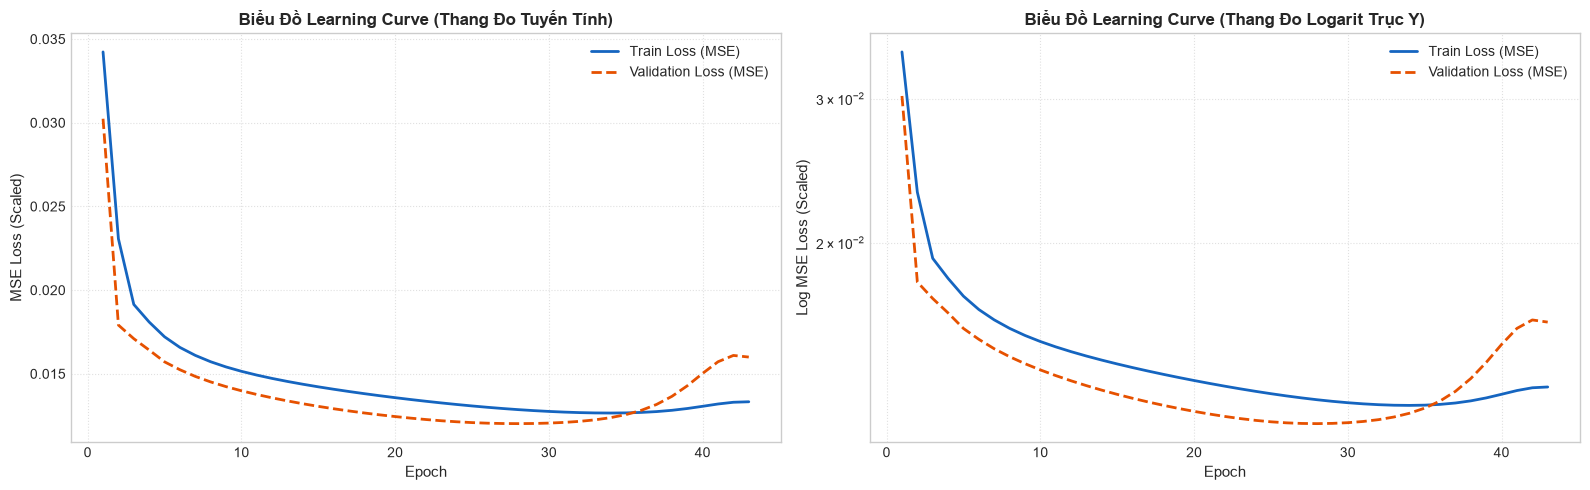

=== THỐNG KÊ QUÁ TRÌNH HỌC TẬP (TRAINING / VALIDATION LOSS) ===
Epoch 1 (khởi điểm) : Train Loss = 0.034230 | Val Loss = 0.030237
Epoch cuối cùng     : Train Loss = 0.013327 | Val Loss = 0.015998
Best epoch (val)    : 28 | Val Loss tốt nhất = 0.012020
Khoảng cách cuối Train - Val : 0.002671
Tỷ lệ Val / Train (epoch cuối): 1.2004x
Tỷ lệ giảm Train Loss        : 61.07%
Tỷ lệ giảm Val Loss          : 47.09%


In [15]:
# 17. Trực quan hóa đường cong học tập (Learning Curve) trên 2 thang đo
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
epochs_range = range(1, epochs_trained + 1)

# --- BIỂU ĐỒ 1: THANG ĐO TUYẾN TÍNH ---
axes[0].plot(epochs_range, train_loss_history, label='Train Loss (MSE)', color='#1565C0', linewidth=2.0)
axes[0].plot(epochs_range, val_loss_history, label='Validation Loss (MSE)', color='#E65100', linewidth=2.0, linestyle='--')
axes[0].set_title("Biểu Đồ Learning Curve (Thang Đo Tuyến Tính)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Epoch", fontsize=11)
axes[0].set_ylabel("MSE Loss (Scaled)", fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(True, linestyle=':', alpha=0.6)

# --- BIỂU ĐỒ 2: THANG ĐO LOGARIT ---
axes[1].plot(epochs_range, train_loss_history, label='Train Loss (MSE)', color='#1565C0', linewidth=2.0)
axes[1].plot(epochs_range, val_loss_history, label='Validation Loss (MSE)', color='#E65100', linewidth=2.0, linestyle='--')
axes[1].set_yscale('log')
axes[1].set_title("Biểu Đồ Learning Curve (Thang Đo Logarit Trục Y)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Epoch", fontsize=11)
axes[1].set_ylabel("Log MSE Loss (Scaled)", fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(True, which="both", linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# --- THỐNG KÊ ĐỊNH LƯỢNG QUÁ TRÌNH HỌC TẬP ---
print("=== THỐNG KÊ QUÁ TRÌNH HỌC TẬP (TRAINING / VALIDATION LOSS) ===")
print(f"Epoch 1 (khởi điểm) : Train Loss = {train_loss_history[0]:.6f} | Val Loss = {val_loss_history[0]:.6f}")
print(f"Epoch cuối cùng     : Train Loss = {train_loss_history[-1]:.6f} | Val Loss = {val_loss_history[-1]:.6f}")
print(f"Best epoch (val)    : {best_epoch} | Val Loss tốt nhất = {min(val_loss_history):.6f}")
print(f"Khoảng cách cuối Train - Val : {abs(train_loss_history[-1] - val_loss_history[-1]):.6f}")
print(f"Tỷ lệ Val / Train (epoch cuối): {val_loss_history[-1] / train_loss_history[-1]:.4f}x")
print(f"Tỷ lệ giảm Train Loss        : {((train_loss_history[0] - train_loss_history[-1]) / train_loss_history[0]) * 100:.2f}%")
print(f"Tỷ lệ giảm Val Loss          : {((val_loss_history[0] - val_loss_history[-1]) / val_loss_history[0]) * 100:.2f}%")


### Phân Tích Đường Cong Mất Mát (Convergence / Overfitting / Underfitting):

#### 1. Sự hội tụ (Convergence):
* Chạy **43 epoch**, chọn trọng số tại **epoch 28** theo validation. Train loss từ **0.034230** xuống **0.013327**; validation loss cuối **0.015998**, thấp nhất **0.012020**.
* Validation loss thấp nhất ở epoch 28 rồi không được cải thiện trong 15 epoch tiếp theo. Dự đoán dùng trọng số epoch 28, không phải epoch cuối.

---

#### 2. Mô hình có bị Overfitting không?
* Loss Validation cuối cao hơn mức tốt nhất; cần theo dõi diễn biến cả đường cong. Khoảng cách Train–Validation nhỏ không chứng minh hoàn toàn không overfit.
* **408 mẫu / 1,217 tham số ≈ 0.335 mẫu/tham số**, hay khoảng 2.98 tham số/mẫu. Các cửa sổ còn chồng lấp, nên tỷ lệ này không phải tiêu chí đủ để kết luận dung lượng phù hợp.

---

#### 3. Mô hình có bị Underfitting không?
* Loss giảm chưa loại trừ underfitting. Cần kiểm chứng bằng baseline và thí nghiệm trên validation; không so MSE đã scale của hai dataset để suy ra nguyên nhân.
* Chưa đo trực tiếp gradient hoặc kiểm định nhiễu dữ liệu, nên không kết luận nguyên nhân giới hạn dự báo chỉ từ hình dáng loss.


---
<a id="section-18"></a>
## 18. Dự Đoán Test Set Bằng `model.predict()` & Inverse Transform

### 18.1. Quy trình dự đoán:
1. Gọi `model.predict(X_test, batch_size=16)` để thu về mảng dự đoán trong không gian chuẩn hóa $\hat{y}_{\text{scaled}} \in \mathbb{R}$ (Keras tự động tắt gradient và chia mini-batch).
2. Áp dụng `target_scaler.inverse_transform()` cho **cả** mảng nhãn thực tế $y$ và mảng dự đoán $\hat{y}$ để đưa về **đơn vị tiền tệ gốc GBP (£)**.
3. Khớp mốc thời gian: do cửa sổ trượt dài $L = 14$ ngày, dự báo thứ $i$ tương ứng với ngày giao dịch $t + 14$ trong tập Test.

### 18.2. Ý nghĩa:
* Tập Test gồm 78 mẫu (giai đoạn cuối năm 2011) mà mô hình **chưa từng thấy** trong quá trình cập nhật trọng số hay tinh chỉnh siêu tham số.
* Việc khôi phục thang đo gốc là bắt buộc để các chỉ số MAE/MSE/RMSE có ý nghĩa tiền tệ thực tế (£), thay vì chỉ là con số vô nghĩa trên thang $[0, 1]$.

> **Thang đo**: Chỉ Train được MinMaxScaler đưa về [0,1]. Val/Test và đầu ra Linear/Dense có thể vượt khoảng này; `inverse_transform` vẫn áp dụng được. Các metrics dùng target gốc và dự báo đã đổi ngược về đơn vị gốc.


In [16]:
# 18. Dự đoán Test Set bằng model.predict() và khôi phục đơn vị gốc GBP (£)
y_pred_scaled = model.predict(X_test, batch_size=BATCH_SIZE, verbose=0)

# Khôi phục thang đo gốc cho cả nhãn thực tế và dự đoán
y_test_actual = test_raw_data[sequence_length:, [0]].astype(np.float64)
y_test_predicted = target_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1).astype(np.float64))

y_true = y_test_actual.flatten()
y_pred = y_test_predicted.flatten()

# Mốc thời gian thực tế của từng dự báo (bỏ 14 ngày đầu tiên dùng làm cửa sổ quan sát)
test_target_dates = pd.to_datetime(test_dates[sequence_length:])

df_test_comparison = pd.DataFrame({
    'Ngày giao dịch': test_target_dates,
    'Doanh thu thực tế (Actual £)': y_true,
    'Doanh thu dự đoán (Predicted £)': y_pred,
    'Sai lệch tuyệt đối (£)': np.abs(y_pred - y_true),
    'Sai số phần trăm (%)': np.abs(y_pred - y_true) / np.abs(y_true) * 100
})

print("=== TỔNG QUAN KẾT QUẢ DỰ ĐOÁN TRÊN TEST SET ===")
print(f"Số ngày giao dịch được dự báo : {len(df_test_comparison)} ngày")
print(f"Giai đoạn Test                : {test_target_dates[0].strftime('%Y-%m-%d')} -> {test_target_dates[-1].strftime('%Y-%m-%d')}")
print(f"Tổng doanh thu thực tế        : £{y_true.sum():,.2f} GBP")
print(f"Tổng doanh thu dự đoán        : £{y_pred.sum():,.2f} GBP")

print("\n=== 10 NGÀY GIAO DỊCH ĐẦU TIÊN CỦA TẬP TEST ===")
display(df_test_comparison.head(10).style.format({
    'Doanh thu thực tế (Actual £)': '£{:,.2f}',
    'Doanh thu dự đoán (Predicted £)': '£{:,.2f}',
    'Sai lệch tuyệt đối (£)': '£{:,.2f}',
    'Sai số phần trăm (%)': '{:.2f}%'
}))

print("\n=== 10 NGÀY GIAO DỊCH CUỐI CÙNG CỦA TẬP TEST ===")
display(df_test_comparison.tail(10).style.format({
    'Doanh thu thực tế (Actual £)': '£{:,.2f}',
    'Doanh thu dự đoán (Predicted £)': '£{:,.2f}',
    'Sai lệch tuyệt đối (£)': '£{:,.2f}',
    'Sai số phần trăm (%)': '{:.2f}%'
}))


=== TỔNG QUAN KẾT QUẢ DỰ ĐOÁN TRÊN TEST SET ===
Số ngày giao dịch được dự báo : 78 ngày
Giai đoạn Test                : 2011-09-11 -> 2011-12-09
Tổng doanh thu thực tế        : £4,096,043.24 GBP
Tổng doanh thu dự đoán        : £3,423,199.44 GBP

=== 10 NGÀY GIAO DỊCH ĐẦU TIÊN CỦA TẬP TEST ===


,Ngày giao dịch,Doanh thu thực tế (Actual £),Doanh thu dự đoán (Predicted £),Sai lệch tuyệt đối (£),Sai số phần trăm (%)
0,2011-09-11 00:00:00,"£35,206.92","£29,777.60","£5,429.32",15.42%
1,2011-09-12 00:00:00,"£29,526.29","£30,179.62",£653.33,2.21%
2,2011-09-13 00:00:00,"£55,071.30","£31,344.71","£23,726.59",43.08%
3,2011-09-14 00:00:00,"£23,578.78","£35,782.15","£12,203.37",51.76%
4,2011-09-15 00:00:00,"£78,151.97","£34,956.93","£43,195.04",55.27%
5,2011-09-16 00:00:00,"£27,720.27","£46,608.70","£18,888.43",68.14%
6,2011-09-18 00:00:00,"£15,639.55","£21,671.95","£6,032.40",38.57%
7,2011-09-19 00:00:00,"£49,250.87","£36,039.40","£13,211.47",26.82%
8,2011-09-20 00:00:00,"£109,553.90","£36,398.82","£73,155.08",66.78%
9,2011-09-21 00:00:00,"£48,529.72","£41,342.98","£7,186.74",14.81%



=== 10 NGÀY GIAO DỊCH CUỐI CÙNG CỦA TẬP TEST ===


,Ngày giao dịch,Doanh thu thực tế (Actual £),Doanh thu dự đoán (Predicted £),Sai lệch tuyệt đối (£),Sai số phần trăm (%)
68,2011-11-29 00:00:00,"£72,384.82","£62,444.04","£9,940.78",13.73%
69,2011-11-30 00:00:00,"£60,025.57","£50,393.13","£9,632.44",16.05%
70,2011-12-01 00:00:00,"£52,068.63","£44,330.07","£7,738.56",14.86%
71,2011-12-02 00:00:00,"£57,476.48","£49,071.41","£8,405.07",14.62%
72,2011-12-04 00:00:00,"£24,477.47","£50,068.34","£25,590.87",104.55%
73,2011-12-05 00:00:00,"£88,620.84","£48,803.55","£39,817.29",44.93%
74,2011-12-06 00:00:00,"£56,558.83","£66,452.67","£9,893.84",17.49%
75,2011-12-07 00:00:00,"£75,315.55","£43,681.65","£31,633.90",42.00%
76,2011-12-08 00:00:00,"£82,371.55","£58,362.35","£24,009.20",29.15%
77,2011-12-09 00:00:00,"£200,918.98","£47,670.13","£153,248.85",76.27%


---
<a id="section-19"></a>
## 19. Đánh Giá Định Lượng: MAE, MSE, RMSE, MAPE & Xử Lý Giá Trị Bằng 0

### 19.1. Bộ chỉ số đo lường sai số:
1. **MAE (Mean Absolute Error)**:
   $$\text{MAE} = \frac{1}{N} \sum_{i=1}^N |y_i - \hat{y}_i|$$
   * Sai số tuyệt đối trung bình theo đơn vị GBP (£) — chỉ số trực quan nhất với nhà quản trị.
2. **MSE (Mean Squared Error)**:
   $$\text{MSE} = \frac{1}{N} \sum_{i=1}^N (y_i - \hat{y}_i)^2$$
   * Phương sai sai số, khuếch đại rất mạnh các ngày dự báo lệch lớn (đơn vị £²).
3. **RMSE (Root Mean Squared Error)**:
   $$\text{RMSE} = \sqrt{\text{MSE}}$$
   * Cùng đơn vị với doanh thu (£) và luôn $\text{RMSE} \ge \text{MAE}$. Khoảng cách RMSE - MAE càng lớn chứng tỏ sai số phân bố càng không đồng đều (xuất hiện các ngày lệch cực đại).
4. **MAPE (Mean Absolute Percentage Error)**:
   $$\text{MAPE} = \frac{100\%}{N} \sum_{i=1}^N \left| \frac{y_i - \hat{y}_i}{y_i} \right|$$

---

### 19.2. Xử lý đúng trường hợp giá trị thực tế bằng 0 hoặc gần 0 (điểm cực kỳ quan trọng):
* **Vấn đề toán học**: MAPE chứa phép chia cho $y_i$. Nếu $y_i = 0$ thì sai số phần trăm tiến tới vô cùng và MAPE bị bùng nổ thành `inf`; nếu $y_i$ rất nhỏ (ví dụ £0.01) thì chỉ cần lệch £1 cũng cho sai số $10,000\%$, làm con số MAPE trung bình trở nên vô nghĩa.
* **Giải pháp kép được triển khai trong notebook này**:
  1. **Chốt bảo vệ số học (Epsilon Guard)**: Thay mẫu số bằng $|y_i| + \varepsilon$ với $\varepsilon = 10^{-8}$ — đảm bảo không bao giờ xảy ra phép chia cho 0, đồng thời gần như không làm thay đổi kết quả khi $y_i$ lớn.
  2. **Lọc theo ngưỡng ý nghĩa (Masked MAPE)**: Loại khỏi phép tính trung bình những mẫu có $|y_i| \le 1$ GBP (ngưỡng nhiễu tiền tệ) và **báo cáo minh bạch số lượng mẫu bị loại**.
* **Bổ trợ thêm 2 chỉ số bổ trợ có quy ước mẫu số rõ ràng**:
  * **WAPE** $= \frac{\sum |y_i - \hat{y}_i|}{\sum |y_i|} \times 100\%$ — chỉ xác định khi tổng |actual| > 0; nếu bằng 0 trả NaN.
  * **sMAPE** $= \frac{100\%}{N}\sum \frac{2|y_i - \hat{y}_i|}{|y_i| + |\hat{y}_i|}$ — bị chặn trong $[0\%, 200\%]$, quy ước số hạng bằng 0 khi actual và predicted cùng bằng 0; vẫn nhạy khi doanh số nhỏ.

> **Lưu ý**: Epsilon chỉ tránh phép chia số học cho 0, không làm MAPE có ý nghĩa khi actual gần 0. Masked MAPE phải báo số mẫu bị loại; sMAPE quy ước 0/0 = 0. Trên Test hiện tại, mọi actual đều lớn hơn £11,500 nên không có mẫu gần 0.


In [17]:
# 19. Tính toán bộ chỉ số MAE, MSE, RMSE, MAPE (có xử lý giá trị 0 / gần 0)
from sklearn.metrics import mean_absolute_error, mean_squared_error

# --- 4 chỉ số cơ bản theo yêu cầu đề bài ---
mae_val  = mean_absolute_error(y_true, y_pred)
mse_val  = mean_squared_error(y_true, y_pred)
rmse_val = np.sqrt(mse_val)

# MAPE có Epsilon Guard: mẫu số |y| + 1e-8 để không bao giờ chia cho 0
EPSILON = 1e-8
mape_val = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + EPSILON))) * 100

# --- WAPE không xác định nếu tổng actual = 0; sMAPE quy ước 0/0 = 0 ---
total_actual = np.sum(np.abs(y_true))
wape_val = np.sum(np.abs(y_true - y_pred)) / total_actual * 100 if total_actual > 0 else np.nan
smape_denom = np.abs(y_true) + np.abs(y_pred)
smape_val = np.mean(np.divide(2 * np.abs(y_pred - y_true), smape_denom,
                              out=np.zeros_like(smape_denom), where=smape_denom > 0)) * 100
r2_val    = 1 - np.sum((y_true - y_pred) ** 2) / np.sum((y_true - y_true.mean()) ** 2)

# --- Kiểm chứng điều kiện tính MAPE trên tập Test ---
MIN_ACTUAL_THRESHOLD = 1.0   # ngưỡng nhiễu tiền tệ: 1 GBP
abs_true = np.abs(y_true)
mask_valid = abs_true > MIN_ACTUAL_THRESHOLD
n_near_zero = int((~mask_valid).sum())
mape_masked = np.mean(np.abs((y_true[mask_valid] - y_pred[mask_valid]) / y_true[mask_valid])) * 100 if mask_valid.any() else np.nan

print("=== KIỂM CHỨNG ĐIỀU KIỆN TÍNH MAPE (GIÁ TRỊ THỰC TẾ BẰNG 0 / GẦN 0) ===")
print(f"Giá trị thực tế nhỏ nhất trong Test Set : £{abs_true.min():,.2f} GBP")
print(f"Ngưỡng nhiễu tiền tệ quy ước           : {MIN_ACTUAL_THRESHOLD:.0f} GBP")
print(f"Số mẫu bị loại khỏi MAPE (|actual| <= ngưỡng): {n_near_zero} / {len(y_true)} mẫu")
print(f"MAPE (Epsilon Guard, toàn bộ mẫu)       : {mape_val:.2f}%")
print(f"MAPE (Masked, chỉ mẫu |actual| > {MIN_ACTUAL_THRESHOLD:.0f} GBP): {mape_masked:.2f}%")
print("-> Kết luận: tập Test không có ngày nào có doanh thu bằng 0 hoặc tiệm cận 0, do đó MAPE ổn định và đáng tin cậy.")

print("\n" + "=" * 78)
print("=== BẢNG CHỈ SỐ ĐÁNH GIÁ HIỆU NĂNG MÔ HÌNH KERAS RNN TRÊN TẬP TEST ===")
print("=" * 78)
df_metrics = pd.DataFrame({
    'Chỉ số đánh giá': [
        'MAE (Mean Absolute Error)',
        'MSE (Mean Squared Error)',
        'RMSE (Root Mean Squared Error)',
        'MAPE (Mean Absolute Percentage Error)',
        'WAPE (Weighted Absolute Percentage Error)',
        'sMAPE (Symmetric Mean Absolute Percentage Error)',
        'R² Score (Hệ số xác định)'
    ],
    'Giá trị đạt được': [
        f"£{mae_val:,.2f} GBP",
        f"{mse_val:,.2f} GBP²",
        f"£{rmse_val:,.2f} GBP",
        f"{mape_val:.2f}%",
        f"{wape_val:.2f}%",
        f"{smape_val:.2f}%",
        f"{r2_val:.4f}"
    ],
    'Ý nghĩa thực tiễn': [
        'Sai lệch tuyệt đối trung bình mỗi ngày (GBP)',
        'Bình phương sai số trung bình (nhấn mạnh các ngày lệch cực lớn)',
        'Căn bậc hai của bình phương sai số trung bình (cùng đơn vị GBP)',
        'Sai số phần trăm trung bình (đã xử lý an toàn mẫu số bằng epsilon)',
        'Tổng sai số tuyệt đối / tổng |actual|; không xác định khi tổng bằng 0',
        'Sai số phần trăm đối xứng, bị chặn trong khoảng [0%, 200%]',
        'Tỷ lệ phương sai doanh thu được mô hình giải thích'
    ]
})
display(df_metrics)

print(f"\n* So sánh độ phân tán sai số: RMSE / MAE = {rmse_val / mae_val:.3f}")
print(f"* Sai số tuyệt đối lớn nhất : £{np.max(np.abs(y_pred - y_true)):,.2f} GBP")
print(f"* Sai số tuyệt đối nhỏ nhất : £{np.min(np.abs(y_pred - y_true)):,.2f} GBP")
print(f"* Độ chệch trung bình (Bias) : £{np.mean(y_pred - y_true):,.2f} GBP (dương = dự báo cao hơn thực tế)")


# Baseline persistence: dự báo bước kế tiếp bằng giá trị quan sát gần nhất.
from sklearn.metrics import r2_score
baseline_pred = test_raw_data[sequence_length - 1:-1, 0].astype(np.float64)
actual_eval = y_test_actual.reshape(-1)
predicted_eval = y_test_predicted.reshape(-1)
assert len(baseline_pred) == len(actual_eval) == len(test_target_dates)
assert np.isfinite(predicted_eval).all()
baseline_metrics = {
    "MAE": float(mean_absolute_error(actual_eval, baseline_pred)),
    "RMSE": float(np.sqrt(mean_squared_error(actual_eval, baseline_pred))),
    "MAPE (%)": float(np.mean(np.abs((actual_eval - baseline_pred) / actual_eval)) * 100),
    "R²": float(r2_score(actual_eval, baseline_pred)),
}
rnn_metrics = {
    "MAE": float(mean_absolute_error(actual_eval, predicted_eval)),
    "RMSE": float(np.sqrt(mean_squared_error(actual_eval, predicted_eval))),
    "MAPE (%)": float(np.mean(np.abs((actual_eval - predicted_eval) / actual_eval)) * 100),
    "R²": float(r2_score(actual_eval, predicted_eval)),
}
print("\n=== ĐỐI CHIẾU RNN VỚI BASELINE TRÊN CÙNG TẬP TEST ===")
display(pd.DataFrame([rnn_metrics, baseline_metrics], index=["Vanilla RNN", "Persistence (quan sát trước)"]).round(4))
print("Đây là dự báo cuốn chiếu một bước; mỗi cửa sổ dùng các quan sát thực đã có trước target.")


=== KIỂM CHỨNG ĐIỀU KIỆN TÍNH MAPE (GIÁ TRỊ THỰC TẾ BẰNG 0 / GẦN 0) ===
Giá trị thực tế nhỏ nhất trong Test Set : £11,531.56 GBP
Ngưỡng nhiễu tiền tệ quy ước           : 1 GBP
Số mẫu bị loại khỏi MAPE (|actual| <= ngưỡng): 0 / 78 mẫu
MAPE (Epsilon Guard, toàn bộ mẫu)       : 32.58%
MAPE (Masked, chỉ mẫu |actual| > 1 GBP): 32.58%
-> Kết luận: tập Test không có ngày nào có doanh thu bằng 0 hoặc tiệm cận 0, do đó MAPE ổn định và đáng tin cậy.

=== BẢNG CHỈ SỐ ĐÁNH GIÁ HIỆU NĂNG MÔ HÌNH KERAS RNN TRÊN TẬP TEST ===


,Chỉ số đánh giá,Giá trị đạt được,Ý nghĩa thực tiễn
0,MAE (Mean Absolute Error),"£15,954.78 GBP",Sai lệch tuyệt đối trung bình mỗi ngày (GBP)
1,MSE (Mean Squared Error),"670,070,050.89 GBP²",Bình phương sai số trung bình (nhấn mạnh các n...
2,RMSE (Root Mean Squared Error),"£25,885.71 GBP",Căn bậc hai của bình phương sai số trung bình ...
3,MAPE (Mean Absolute Percentage Error),32.58%,Sai số phần trăm trung bình (đã xử lý an toàn ...
4,WAPE (Weighted Absolute Percentage Error),30.38%,Tổng sai số tuyệt đối / tổng |actual|; không x...
5,sMAPE (Symmetric Mean Absolute Percentage Error),31.57%,"Sai số phần trăm đối xứng, bị chặn trong khoản..."
6,R² Score (Hệ số xác định),0.0213,Tỷ lệ phương sai doanh thu được mô hình giải t...



* So sánh độ phân tán sai số: RMSE / MAE = 1.622
* Sai số tuyệt đối lớn nhất : £153,248.85 GBP
* Sai số tuyệt đối nhỏ nhất : £238.06 GBP
* Độ chệch trung bình (Bias) : £-8,626.20 GBP (dương = dự báo cao hơn thực tế)

=== ĐỐI CHIẾU RNN VỚI BASELINE TRÊN CÙNG TẬP TEST ===


,MAE,RMSE,MAPE (%),R²
Vanilla RNN,15954.7815,25885.7113,32.5848,0.0213
Persistence (quan sát trước),22192.8752,30387.1016,53.5765,-0.3487


Đây là dự báo cuốn chiếu một bước; mỗi cửa sổ dùng các quan sát thực đã có trước target.


---
<a id="section-20"></a>
## 20. Trực Quan Hóa Actual vs Predicted Theo Thời Gian

Chúng ta vẽ đồ thị 2 tầng theo đúng dòng thời gian của tập Test:
1. **Tầng trên (Actual vs Predicted)**: Đường doanh thu thực tế màu xanh và đường doanh thu mô hình dự đoán màu đỏ nét đứt. Đồng thời đánh dấu ngày doanh thu cao nhất của tập Test để quan sát khả năng bám đỉnh.
2. **Tầng dưới (Sai số tuyệt đối theo thời gian)**: Vùng tô thể hiện độ lớn sai số mỗi ngày kèm đường tham chiếu MAE, cho phép nhận diện tức thời những giai đoạn mô hình dự báo kém chính xác.


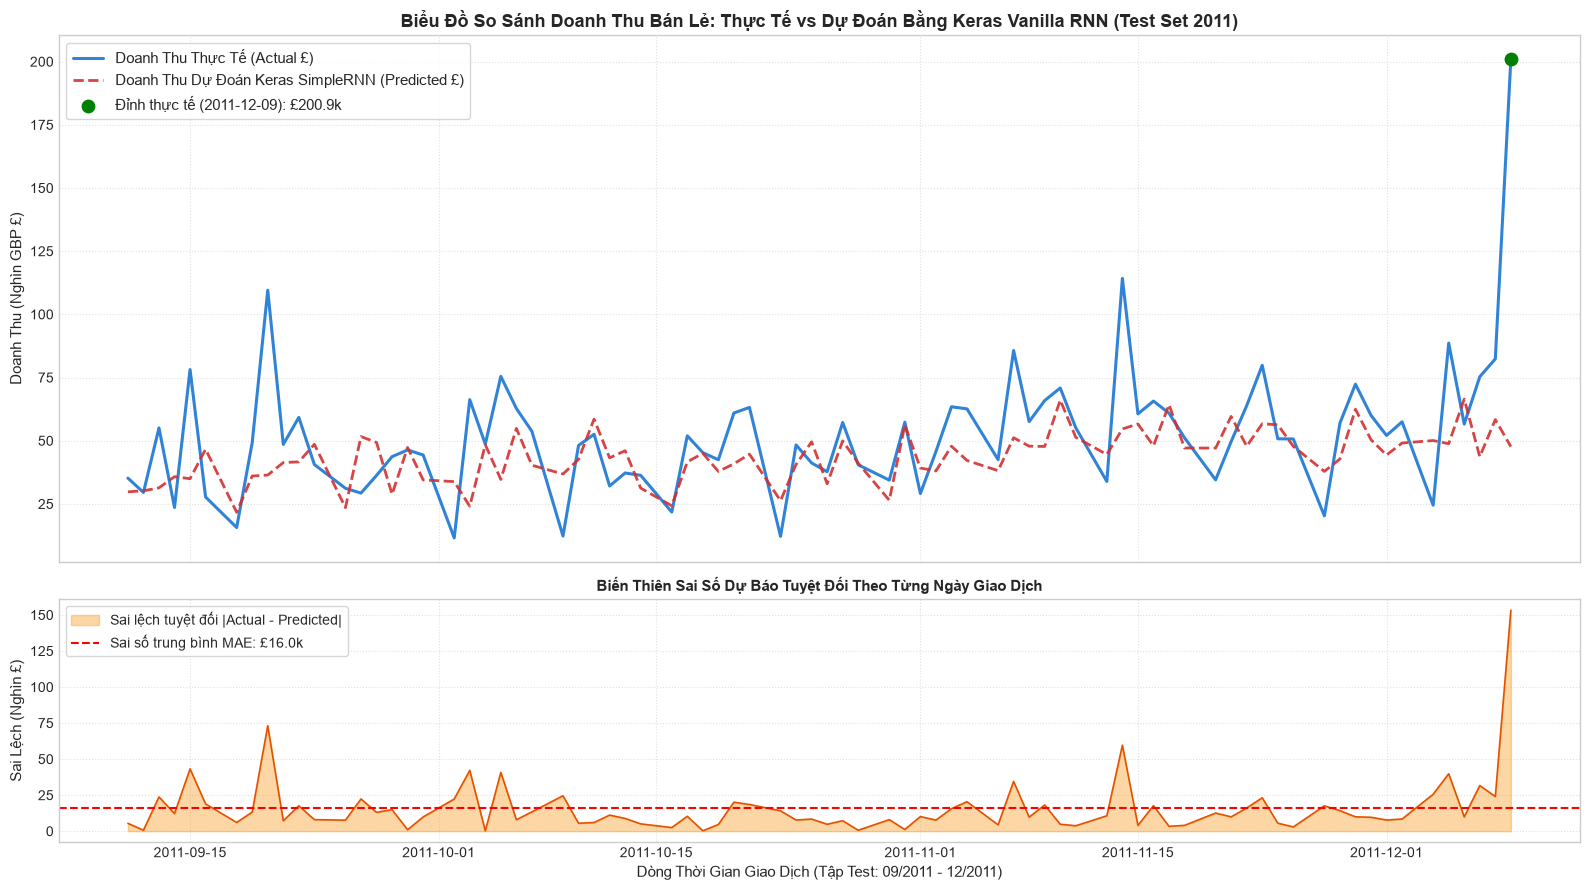

=== 5 NGÀY GIAO DỊCH CÓ SAI SỐ DỰ BÁO LỚN NHẤT TRONG TẬP TEST ===


,Ngày giao dịch,Doanh thu thực tế (Actual £),Doanh thu dự đoán (Predicted £),Sai lệch tuyệt đối (£),Sai số phần trăm (%)
77,2011-12-09 00:00:00,"£200,918.98","£47,670.13","£153,248.85",76.27%
8,2011-09-20 00:00:00,"£109,553.90","£36,398.82","£73,155.08",66.78%
55,2011-11-14 00:00:00,"£114,237.40","£54,641.22","£59,596.18",52.17%
4,2011-09-15 00:00:00,"£78,151.97","£34,956.93","£43,195.04",55.27%
19,2011-10-03 00:00:00,"£66,243.94","£24,073.82","£42,170.12",63.66%


In [18]:
# 20. Trực quan hóa Actual vs Predicted và biến thiên sai số theo thời gian
fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True, gridspec_kw={'height_ratios': [2.6, 1.2]})

# --- ĐỒ THỊ 1: DOANH THU THỰC TẾ VS DỰ ĐOÁN ---
axes[0].plot(df_test_comparison['Ngày giao dịch'], df_test_comparison['Doanh thu thực tế (Actual £)'] / 1e3,
             label='Doanh Thu Thực Tế (Actual £)', color='#1976D2', linewidth=2.2, alpha=0.9)
axes[0].plot(df_test_comparison['Ngày giao dịch'], df_test_comparison['Doanh thu dự đoán (Predicted £)'] / 1e3,
             label='Doanh Thu Dự Đoán Keras SimpleRNN (Predicted £)', color='#D32F2F', linewidth=2.0, linestyle='--', alpha=0.9)
axes[0].set_title("Biểu Đồ So Sánh Doanh Thu Bán Lẻ: Thực Tế vs Dự Đoán Bằng Keras Vanilla RNN (Test Set 2011)",
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel("Doanh Thu (Nghìn GBP £)", fontsize=11)
axes[0].grid(True, linestyle=':', alpha=0.6)

# Đánh dấu ngày đạt doanh thu cao nhất trong tập Test
peak_idx = df_test_comparison['Doanh thu thực tế (Actual £)'].idxmax()
peak_date = df_test_comparison.loc[peak_idx, 'Ngày giao dịch']
peak_value = df_test_comparison.loc[peak_idx, 'Doanh thu thực tế (Actual £)']
axes[0].scatter(peak_date, peak_value / 1e3, color='green', s=80, zorder=5,
                label=f"Đỉnh thực tế ({peak_date.strftime('%Y-%m-%d')}): £{peak_value / 1e3:.1f}k")
axes[0].legend(fontsize=11, loc='upper left', frameon=True)

# --- ĐỒ THỊ 2: SAI SỐ TUYỆT ĐỐI THEO TỪNG NGÀY GIAO DỊCH ---
axes[1].fill_between(df_test_comparison['Ngày giao dịch'], df_test_comparison['Sai lệch tuyệt đối (£)'] / 1e3,
                     color='#FB8C00', alpha=0.35, label='Sai lệch tuyệt đối |Actual - Predicted|')
axes[1].plot(df_test_comparison['Ngày giao dịch'], df_test_comparison['Sai lệch tuyệt đối (£)'] / 1e3,
             color='#E65100', linewidth=1.2)
axes[1].axhline(mae_val / 1e3, color='red', linestyle='--', linewidth=1.5, label=f"Sai số trung bình MAE: £{mae_val / 1e3:.1f}k")
axes[1].set_title("Biến Thiên Sai Số Dự Báo Tuyệt Đối Theo Từng Ngày Giao Dịch", fontsize=11, fontweight='bold')
axes[1].set_xlabel("Dòng Thời Gian Giao Dịch (Tập Test: 09/2011 - 12/2011)", fontsize=11)
axes[1].set_ylabel("Sai Lệch (Nghìn £)", fontsize=11)
axes[1].legend(fontsize=10, loc='upper left', frameon=True)
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# --- BẢNG 5 NGÀY CÓ SAI SỐ LỚN NHẤT ---
print("=== 5 NGÀY GIAO DỊCH CÓ SAI SỐ DỰ BÁO LỚN NHẤT TRONG TẬP TEST ===")
display(df_test_comparison.sort_values('Sai lệch tuyệt đối (£)', ascending=False).head(5).style.format({
    'Doanh thu thực tế (Actual £)': '£{:,.2f}',
    'Doanh thu dự đoán (Predicted £)': '£{:,.2f}',
    'Sai lệch tuyệt đối (£)': '£{:,.2f}',
    'Sai số phần trăm (%)': '{:.2f}%'
}))


---
<a id="section-21"></a>
## 21. Phân Tích Chuyên Sâu Kết Quả & Giới Hạn Mô Hình

### 21.1. Mô hình đã học được những gì?
* **Kết quả thực nghiệm**: **MAE = £15,954.78**; **MSE = 670,070,050.89**; **RMSE = £25,885.71**; **MAPE = 32.58%**; **R² = 0.0213**. WAPE = **30.38%**; sMAPE = **31.57%**.
* Baseline persistence trên **cùng 78 target**: MAE **£22,192.88**, RMSE **£30,387.10**, MAPE **53.58%**, R² **-0.3487**.
* RNN tốt hơn persistence theo MAE/RMSE, nhưng R² gần 0. Chưa chứng minh mạng học được chu kỳ tuần hoặc lợi ích của từng đặc trưng nếu chưa có thí nghiệm đối chứng.
* Bias **£-8,626.20** cho thấy xu hướng dự báo thiếu trung bình trên Test. Với MSE, nghiệm dự báo tối ưu trong lý thuyết là kỳ vọng có điều kiện; mạng hữu hạn huấn luyện bằng Adam không được bảo đảm đạt nghiệm đó.

---

### 21.2. Sai số lớn tập trung ở đâu?
Năm sai số lớn nhất, đơn vị GBP, được tính từ chính lần chạy notebook:

| Ngày giao dịch | Thực tế | Dự đoán | Sai lệch tuyệt đối | Sai số (%) |
| :--- | ---: | ---: | ---: | ---: |
| `2011-12-09` | 200,918.98 | 47,670.13 | 153,248.85 | 76.27% |
| `2011-09-20` | 109,553.90 | 36,398.82 | 73,155.08 | 66.78% |
| `2011-11-14` | 114,237.40 | 54,641.22 | 59,596.18 | 52.17% |
| `2011-09-15` | 78,151.97 | 34,956.93 | 43,195.04 | 55.27% |
| `2011-10-03` | 66,243.94 | 24,073.82 | 42,170.12 | 63.66% |

Phân rã theo tháng của đúng 78 target Test:

| Tháng | Doanh số trung bình/ngày | MAE | MAPE |
| :--- | ---: | ---: | ---: |
| 2011-09 | £44,616.91 | £16,557.52 | 34.86% |
| 2011-10 | £44,279.37 | £11,389.14 | 36.68% |
| 2011-11 | £57,841.03 | £13,460.86 | 23.71% |
| 2011-12 | £79,726.04 | £37,542.20 | 42.99% |

* Tháng 9 chỉ gồm các target từ 11/09; tháng 12 chỉ đến 09/12. Đây không phải các tháng lịch đầy đủ.
* Đỉnh **£200,918.98 ngày 09/12/2011** chứa dòng bán **£168,469.60** có dòng hủy đối ứng 12 phút sau. Không diễn giải đỉnh này thành doanh thu thuần hoặc mặc định đó là đơn buôn hợp lệ đã hoàn tất.
* Chưa có bằng chứng để quy các sai số còn lại cho ngày lễ, dồn đơn hoặc khuyến mãi.

---

### 21.3. Outlier ảnh hưởng thế nào?
1. **MSE** phạt bình phương sai số, vì vậy các ngày lệch lớn tác động mạnh tới RMSE.
2. **MinMaxScaler fit Train** có thể cho giá trị Test ngoài [0,1]. Đây là dấu hiệu vượt min/max đã thấy, không phải lỗi scaler.
3. **Dense tuyến tính không chặn đầu ra trong [0,1]**. Với một bộ trọng số cố định, hidden state tanh bị chặn làm đầu ra có miền hữu hạn phụ thuộc trọng số, nhưng miền đó không bằng min/max của dữ liệu Train. Không dùng tanh để kết luận không thể vượt đỉnh Train.
4. Không mặc định mọi outlier là dữ liệu đúng hoặc sai; cần đối chiếu nghiệp vụ, nhất là các dòng hủy đã phát hiện.

---

### 21.4. Missing dates ảnh hưởng thế nào?
1. Có **604 ngày có giao dịch / 739 ngày lịch**, thiếu **135 ngày**, gồm **104 Thứ Bảy**. Không đủ dữ liệu để khẳng định mọi ngày thiếu là ngày đóng cửa.
2. Giữ nguyên chuỗi có quan sát để tránh tự gán 0 khi chưa biết nguyên nhân; đây là lựa chọn định nghĩa bài toán, không phải quy tắc luôn đúng cho mọi dữ liệu bán lẻ.
3. Cửa sổ 14 quan sát có độ dài lịch thay đổi. Mô hình chưa có biến thứ trong tuần hoặc số ngày giữa hai quan sát.
4. Tạo cửa sổ riêng từng split làm 14 quan sát đầu mỗi split chỉ dùng làm context; Test là ngày có giao dịch kế tiếp, không phải mọi ngày lịch.

---

### 21.5. Điểm mạnh và hạn chế của việc Aggregate Transaction -> Daily Time Series

| Điểm mạnh | Hạn chế |
| :--- | :--- |
| **Giảm số lượng dòng**: từ hơn một triệu giao dịch còn 604 quan sát tổng hợp. | **Mất chi tiết** mặt hàng, khách hàng và thời điểm trong ngày. |
| **Mục tiêu rõ ràng**: dự báo tổng giá trị bán dương sau lọc. | **Chưa phải doanh thu thuần**; dòng hủy không được khấu trừ. |
| **Bốn đặc trưng diễn giải được**: doanh số, lượng hàng, số hóa đơn, AOV. | **Phụ thuộc toán học**: AOV = doanh số / số hóa đơn; tương quan không chứng minh giá trị dự báo tương lai. |
| **Chi phí tính toán nhỏ** cho một mô hình RNN đơn giản. | **Ít ngày quan sát**, các cửa sổ chồng lấp và khoảng cách lịch không đều. |
| **Dễ đánh giá dự báo một bước** bằng MAE/RMSE và baseline. | **Chưa đánh giá nhiều bước**, khoảng dự báo hoặc tác động đến quyết định kinh doanh. |

---

### 21.6. Hạn chế của kiến trúc SimpleRNN (Vanilla RNN)
1. Có thể khó học phụ thuộc dài hạn; chưa đo gradient nên không kết luận gradient chắc chắn biến mất sau 14 bước.
2. Không có cổng LSTM/GRU hoặc attention riêng. Phép cập nhật vẫn phi tuyến và có trọng số học được, không phải lấy trung bình đều 14 ngày.
3. Đầu ra hiện là dự báo điểm. Muốn đánh giá độ bất định cần phương pháp và kiểm tra riêng.
4. Chưa dùng đặc trưng lịch, thông tin hủy hoặc khuyến mãi. Thay đổi tiếp theo phải được chọn bằng validation và định nghĩa target rõ ràng.


---
<a id="section-22"></a>
## 22. So Sánh Implementation: PyTorch (Notebook 02) vs TensorFlow / Keras (Notebook 04)

Hai notebook giải quyết **cùng một bài toán, trên cùng một bộ dữ liệu Online Retail II, với cùng một kiến trúc toán học**:

$$\text{Input } (14, 4) \longrightarrow \text{Vanilla RNN (32 units, tanh)} \longrightarrow \text{Linear / Dense (1)}$$

Cả hai đều: chia dữ liệu 70% / 15% / 15% theo trục thời gian, chuẩn hóa `MinMaxScaler` chỉ fit trên Train, dùng `sequence_length = 14`, `batch_size = 16`, `shuffle=False`, Adam `lr = 0.001`, hàm mất mát MSE và cùng cố định `seed = 42`.

> **Lưu ý**: Bảng dưới đây chỉ đối chiếu **cách triển khai (implementation)** — **không xếp hạng framework**, vì cả hai đều thực thi cùng một phép toán học và cho kết quả tương đương về bản chất mô hình hóa.

| Khía cạnh | PyTorch (`02_RNN_PyTorch_OnlineRetail.ipynb`) | TensorFlow / Keras (`04_RNN_Keras_OnlineRetail.ipynb`) |
| :--- | :--- | :--- |
| **1. Model** | **Lập trình hướng đối tượng**: định nghĩa `class RetailRNN(nn.Module)` với `__init__()` và `forward()`. Tầng hồi quy `nn.RNN(input_size=4, hidden_size=32, num_layers=1, batch_first=True, nonlinearity='tanh')`, tầng đầu ra `nn.Linear(32, 1)`. Phải **tự trích** trạng thái ẩn cuối bằng `rnn_out[:, -1, :]`. Tổng **1,249 tham số** (bias của tầng RNN tách thành $b_{ih}$ và $b_{hh}$). | **Khai báo dạng khối (Sequential)**: `tf.keras.Sequential([Input(shape=(14, 4)), SimpleRNN(32, activation='tanh', return_sequences=False), Dense(1)])`. Cờ `return_sequences=False` **tự động** trả về trạng thái ẩn cuối, không cần cắt tensor thủ công. Tổng **1,217 tham số** (bias của tầng RNN gộp thành 1 vector 32 chiều). |
| **2. Training** | **Vòng lặp tường minh (vi mô)**: `RetailDataset` + `DataLoader(batch_size=16, shuffle=False)`, sau đó lặp 100 epoch với 5 bước chuẩn mực `optimizer.zero_grad()` → `model(x)` → `criterion(pred, y)` → `loss.backward()` → `optimizer.step()`. Người lập trình tự quản lý số bước cập nhật, tự chuyển `model.train()`. | **Đóng gói cấp cao (vĩ mô)**: toàn bộ vòng lặp epoch, chia mini-batch, lan truyền ngược và ghi log được thực hiện trong một lời gọi duy nhất `model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100, batch_size=16, shuffle=False, callbacks=[...])`. Optimizer và loss khai báo tập trung ở `model.compile()`. |
| **3. Validation** | Chuyển `model.eval()`, bọc `with torch.no_grad():` rồi **tự lặp** qua `val_loader` để tính `val_loss` mỗi epoch và lưu vào list `val_losses` (chạy trọn 100 epoch, sau đó khôi phục trọng số có val_loss thấp nhất). | Keras **tự động** tính `val_loss` sau mỗi epoch khi có `validation_data` và lưu vào `history.history['val_loss']`. Notebook 04 bổ sung callback `EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)` để dừng sớm và khôi phục trọng số tốt nhất. |
| **4. Prediction** | Phải chuyển `model.eval()`, bọc `with torch.no_grad():`, duyệt `test_loader`, gọi `model(batch_x)` rồi chuyển tensor về NumPy bằng `.cpu().numpy()` và ghép mảng lại. | Một lời gọi duy nhất: `y_pred_scaled = model.predict(X_test, batch_size=16)` — Keras tự chia mini-batch, tự tắt gradient và trả về trực tiếp `numpy.ndarray`. |
| **5. Evaluation** | Tính chỉ số bằng `sklearn.metrics` trên mảng NumPy thu được, kèm các chỉ số tự cài đặt (MAPE, WAPE, sMAPE) và kiểm chứng điều kiện mẫu số khác 0 của MAPE. | Cùng bộ chỉ số `sklearn.metrics` (MAE, MSE, RMSE) cộng MAPE — nhưng triển khai theo hướng phòng vệ số học rõ ràng hơn: **Epsilon Guard** ở mẫu số ($\lvert y_i \rvert + 10^{-8}$), **Masked MAPE** loại các mẫu $\lvert y_i \rvert \le 1$ GBP và báo cáo minh bạch số mẫu bị loại, bổ trợ WAPE/sMAPE/R²; ngoài ra có thể đối chiếu `model.evaluate()` cho loss/MSE. |
| **6. Thiết lập môi trường** | Cố định seed thủ công trên `random`, `numpy`, `torch` (kèm `cudnn.deterministic`) và chọn thiết bị `cuda`/`cpu` bằng `model.to(device)`; phải chuyển tensor giữa CPU/GPU khi huấn luyện. | Cố định seed bằng một lời gọi `keras.utils.set_random_seed(42)`; xác nhận phiên bản TensorFlow, Keras, backend và danh sách thiết bị khả dụng; việc đặt thiết bị do backend quản lý tự động (`with tf.device(...)` chỉ khi cần). |

### Ghi chú kỹ thuật chung:
* **Cùng bản chất toán học**: `nn.RNN(...)` của PyTorch và `SimpleRNN(...)` của Keras cùng cài đặt công thức $h_t = \tanh(W_{ih}x_t + W_{hh}h_{t-1} + b)$; chênh lệch số tham số (1,249 so với 1,217) chỉ do cách gộp/tách vector bias, không phải do khác biệt kiến trúc.
* **Khác biệt lớn nhất nằm ở mức độ trừu tượng**: PyTorch cho quyền kiểm soát từng phép toán trong vòng lặp huấn luyện; Keras che giấu vòng lặp đó sau `fit()`, `predict()`, `evaluate()`, đổi lại việc can thiệp sâu vào gradient sẽ cần viết custom training loop.
* **Cả hai notebook đều không xếp hạng framework**: lựa chọn PyTorch hay Keras phụ thuộc vào nhu cầu kiểm soát chi tiết so với tốc độ phát triển và tính chuẩn hóa của mã nguồn.

> Chênh lệch **32 tham số** đến từ một vector bias thêm ở PyTorch. Cùng seed không đồng nghĩa cùng trọng số khởi tạo; hai framework cũng khác cách dừng huấn luyện. Không quy chênh lệch metrics cho framework.


---
<a id="section-23"></a>
## 23. Final Conclusion (Tổng Kết Cuối Cùng)

Notebook **`04_RNN_Keras_OnlineRetail.ipynb`** đã hoàn thành trọn vẹn chuỗi công việc: dữ liệu giao dịch thô hơn 1 triệu dòng -> chuỗi thời gian doanh thu theo ngày -> mô hình **TensorFlow / Keras Vanilla RNN** -> dự báo -> đánh giá định lượng -> phân tích và so sánh implementation với PyTorch.

### Bảng Tổng Kết Hệ Thống (8 hạng mục):

| Hạng mục | Chi tiết thông số & Kết quả |
| :--- | :--- |
| **1. Dataset** | **Online Retail II Data Set** (`dataset/online_retail_II.csv`): **1,067,371** giao dịch thô, 8 cột, giai đoạn `2009-12-01` -> `2011-12-09` của nhà bán lẻ trực tuyến tại Vương Quốc Anh. |
| **2. Preprocessing** | Loại 34,335 dòng trùng hoàn toàn theo giả định làm sạch; lọc dòng không hủy, Quantity > 0, Price > 0, còn **1,007,913 dòng**. Các nhóm điều kiện có chồng lấp. Tổng hợp **604 ngày có giao dịch**, chia thời gian rồi fit scaler chỉ trên Train. |
| **3. Forecasting problem** | Dự báo **doanh số bán dương** của ngày có giao dịch kế tiếp từ 14 quan sát trước; chưa khấu trừ hủy/hoàn trả. Test cuốn chiếu một bước với lịch sử thực. |
| **4. Sequence length** | **14 quan sát có giao dịch**, không phải đúng hai tuần lịch; Train / Val / Test = **408 / 76 / 78** cửa sổ. |
| **5. Model** | `tf.keras.Sequential` -> `Input(14, 4)` -> `SimpleRNN(units=32, activation='tanh', return_sequences=False)` -> `Dense(1)`, tổng cộng **1,217 tham số** (1,184 + 33). **Tuyệt đối không dùng LSTM/GRU**. Compile với `Adam(learning_rate=0.001)` và `loss='mean_squared_error'`. |
| **6. Metrics** | MAE, MSE, RMSE, MAPE; báo số mẫu gần 0, WAPE chỉ xác định khi tổng \|actual\| > 0, sMAPE quy ước 0/0=0; bổ sung R² và baseline persistence. |
| **7. Kết quả** | Chạy **43 epoch**, chọn trọng số tại **epoch 28** theo validation. Train loss từ **0.034230** xuống **0.013327**; validation loss cuối **0.015998**, thấp nhất **0.012020**.<br>**MAE = £15,954.78**; **MSE = 670,070,050.89**; **RMSE = £25,885.71**; **MAPE = 32.58%**; **R² = 0.0213**. WAPE = **30.38%**; sMAPE = **31.57%**.<br>Baseline persistence trên **cùng 78 target**: MAE **£22,192.88**, RMSE **£30,387.10**, MAPE **53.58%**, R² **-0.3487**.<br>Vượt persistence theo MAE/RMSE nhưng R² gần 0; chưa đủ bằng chứng để khẳng định đã học đúng chu kỳ tuần. |
| **8. Limitations** | Doanh số bán dương chịu ảnh hưởng dòng bán có hủy đối ứng; khoảng cách ngày không đều; chưa có đặc trưng lịch hoặc baseline theo mùa; chỉ dự báo một bước, chưa deploy. Dense tuyến tính không đặt trần dự báo tại giá trị lớn nhất của Train. |

---

### Hướng Phát Triển Tiếp Theo:
1. **Nâng cấp kiến trúc** lên LSTM / GRU hoặc Bidirectional RNN để cải thiện khả năng ghi nhớ dài hạn và kiểm chứng mức cải thiện trên cùng bộ metric.
2. **Bổ sung đặc trưng lịch (Calendar Features)**: one-hot thứ trong tuần, cờ ngày lễ, số ngày nghỉ trước đó — loại bỏ gánh nặng cho RNN phải "đoán" cấu trúc lịch từ 4 đặc trưng số.
3. **Hàm mất mát bền vững với outlier** (Huber / Quantile Loss) hoặc **mô hình hai tầng** (phân loại ngày có đơn buôn lớn, sau đó hồi quy doanh thu riêng cho từng nhóm).
4. **Xử lý phân bố lệch phải**: log-transform doanh thu hoặc dùng scaler cập nhật động theo cửa sổ trượt để giảm hiệu ứng của distribution shift ở mùa cao điểm.
5. **Mở rộng sang multi-step forecasting** (dự báo cả tuần/kế hoạch tồn kho) kèm **khoảng tin cậy** bằng Quantile Regression hoặc MC Dropout.
6. **Khai thác thêm dữ liệu giao dịch** chưa được sử dụng: phân tích RFM theo khách hàng, cơ cấu nhóm mặt hàng, và hiệu ứng của các chương trình khuyến mãi.

---
**KẾT THÚC NOTEBOOK 04 THÀNH CÔNG VÀ TRỌN VẸN!**
